<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2026/blob/main/Module%203/Midterm_1_F2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Midterm 1, MSE 504, 202**

- Instructor: Sergei V. Kalinin
- TA: Kamyar Barakati

Special instructions:
- please add your name and department
- please share the midterm **both** with instructor (to gmail account) and TA
- (parenthetically, make sure that all the previous homeworks are shared with Aditya as well!)
- choose 2 out of 3 problems (I. Elements, II. Spectra, III. Images) below as a Midterm 1.

# I. Element Analysis

Use the Matminer to create a table of element descriptors, and explore correlations and classification.

In [1]:
!pip install matminer
!pip install mdf_forge
!pip -q install mdf-toolbox mdf-forge
!pip install figrecipes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 31.5 MB/s eta 0:00:00
   ━━━━━

1. Download the MatMiner data set of your choice (e.g. castelli perovskites, mechanical properties, JARVIS data sets, etc). The instructions will be on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html. Choose the data set that best aligns with your research interests. Ideally, the data set will contain composition information and several properties. Use the notebooks on course GitHub or (even better) original MatMiner website as examples.

2. Featurize the data set, e.g. using compositional and structural MagPie features.

With this, you will get a data set containing certain number of compounds, their properties (dependent on the data set you have chosen it can be bandgap, mechanical, dielectric constants, etc), and an associated descriptor vector.

### Problem I.1. Clustering of Elements

I.1.1. Now, create labels. You can:
- Use your property column to classify the materials as metals (bandgap <0.01, semiconductors (0.0.1 < bandgap < 0.3), and dielectrics (bandgap >0.3).
- Or do the same for the mechnical properties, melting temperatures, and so on. Note that this classification will be somewhat ad hoc (but then classification based on numerical parameters is a special case of regression)

With that, using the MagPie features, show the
- UMap
- t-SNE

representations. Visualize the distribution of classes in this space by superimposing the class labels on top of the graphs.

I.1.2. Dimensionality reduction. Use PCA to dimensionally reduce the magPie labels.
- Plot the resulting data sets using the labels you have created. Is any strucutre obvious in the distributions?
- Plot the strucutre of the PCA eigenvectors.

I.1.3. Use the GMM to cluster the MagPie descriptors.
- Visualize the GMM labels in the PCA space for descripotrs
- Calculate the correlation matrics between your clases and GMM descriptors.

I.1.4. Perform the Canonical Correlation Analysis between the MagPie descriptors and the properties. Show the CCA scores and eigenvecotrs. Using domain intuition and ChatGPT, explore the meaning of correlations.

### Problem I.2.Supervised learning

I.2.1. Simple classification
- Build the decision tree classifier for your labels.
- Calculate confusion matrix, ROC, and AUC.
- Explore the effect of classifier depth on AUC

I.2.2. LDA or QDA. Now use the LDA (or QDA) to classify the elements using 2 of the labels you have created as targets.
- Visualize the resulting distributions.
- If you have more then two labels (e.g. metal, dielectric, semicondutor) explore where the third label will be localized.
- Visualize the LDA (QDA) eigenvectors.

# II. Classification of spectral data

Let's explore and analyze the cathodoluminiscence data from hybrid perovskite solid solutions. Use the ChatGPT to explore how the CL spectra are acquired and what we can learn from them.

In [2]:
!pip install atomai pyroved

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.6 MB/s eta 0:00:00
  Created wheel for mendeleev: filename=mendeleev-0.6.1-py2.py3-none-any.whl size=175054 sha256=1472f1ae76361e58b3820cb27cae6aabce8a0e2bb2c0148ce390cd960f3b5735
  Stored in directory: /root/.cache/pip/wheels/79/b3/93/fce7f281f5581aae3887f1d60c9c091a96e784e2ce0833500c
Successfully built mendeleev


In [3]:
from copy import deepcopy as dc

import numpy as np
import torch
import h5py

from scipy import ndimage
from sklearn import decomposition

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import pyroved as pv
import atomai as aoi
import matplotlib.pyplot as plt

# Libraries for data processing and machine learning
from sklearn.linear_model import Perceptron, LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc, adjusted_rand_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
# For image/data manipulation
from scipy.ndimage import zoom

Let's import 4 data sets.

In [4]:
!gdown https://drive.google.com/uc?id=11h-E07ytavAjd2VNtwZUSnfc0sY-RDBt
!gdown https://drive.google.com/uc?id=1MlCxquvM94lMoWa3Yhmc-pZ7TfqbwEN0
!gdown https://drive.google.com/uc?id=1VYR0LouoEbWk8pr5-7WjH_k2INqTmr1P
!gdown https://drive.google.com/uc?id=1xEWo5hOsS59HAq6b-x-D3NWkfC9bC6iN

Downloading...
From: https://drive.google.com/uc?id=11h-E07ytavAjd2VNtwZUSnfc0sY-RDBt
To: /content/0220415_D45_30kx_5kV_32pA_LV_200ms_119X80_40nm_1_corrected.h5
100% 19.8M/19.8M [00:00<00:00, 84.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MlCxquvM94lMoWa3Yhmc-pZ7TfqbwEN0
To: /content/0220415_D48_30kx_5kV_32pA_LV_400ms_119X80_40nm_2_corrected.h5
100% 19.7M/19.7M [00:00<00:00, 74.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VYR0LouoEbWk8pr5-7WjH_k2INqTmr1P
To: /content/0220418_D50_30kx_5kV_32pA_LV_400ms_119X80_40nm_1MHz_8g_re_corrected (1).h5
100% 15.4M/15.4M [00:00<00:00, 33.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xEWo5hOsS59HAq6b-x-D3NWkfC9bC6iN
To: /content/20220510_D17_30kx_5kV_32pA_LV_400ms_119X80_40nm_1MHz_3g_corrected.h5
100% 49.5M/49.5M [00:00<00:00, 51.3MB/s]


In [5]:
h5_f1 = h5py.File(r'/content/0220415_D45_30kx_5kV_32pA_LV_200ms_119X80_40nm_1_corrected.h5', 'r+')
h5_f2 = h5py.File(r'/content/0220415_D48_30kx_5kV_32pA_LV_400ms_119X80_40nm_2_corrected.h5', 'r+')
#h5_f3 = h5py.File(r'/content/0220418_D50_30kx_5kV_32pA_LV_400ms_119X80_40nm_1MHz_8g_re_corrected (1).h5', 'r+')
h5_f4 = h5py.File(r'/content/20220510_D17_30kx_5kV_32pA_LV_400ms_119X80_40nm_1MHz_3g_corrected.h5', 'r+')

... and explore their structure. Use ChatGPT to explore what is hdf5 and why it is convenient way to store instrumental data.

In [6]:
print(h5_f4.keys())
print(h5_f4['Acquisition2'].keys())
print(h5_f4['Acquisition2']['ImageData'].keys())

<KeysViewHDF5 ['Acquisition0', 'Acquisition1', 'Acquisition2']>
<KeysViewHDF5 ['ImageData', 'PhysicalData', 'SVIData', 'StateEnumeration']>
<KeysViewHDF5 ['DimensionScaleC', 'DimensionScaleX', 'DimensionScaleY', 'DimensionScaleZ', 'Image', 'PrimaryGlassMediumInterfacePosition', 'SecondaryGlassMediumInterfacePosition', 'TOffset', 'XOffset', 'YOffset', 'ZOffset']>


(1, 1, 1, 3840, 5760)


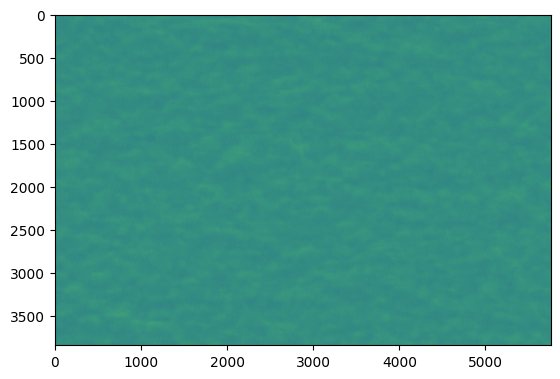

In [7]:
print(h5_f4['Acquisition0']['ImageData']['Image'].shape)
im0 = np.squeeze(h5_f4['Acquisition0']['ImageData']['Image'])
plt.imshow(im0)

(1, 1, 1, 1280, 1904)


(np.float64(-0.5), np.float64(1903.5), np.float64(1279.5), np.float64(-0.5))

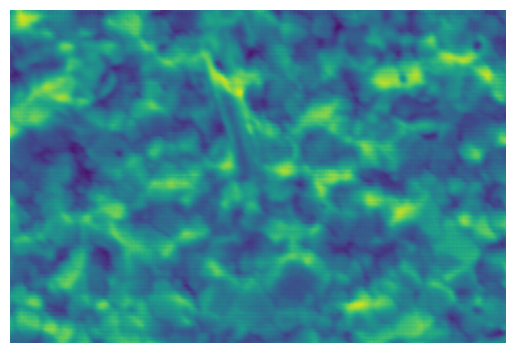

In [8]:
print(h5_f4['Acquisition1']['ImageData']['Image'].shape)
im1 = np.squeeze(h5_f4['Acquisition1']['ImageData']['Image'])
plt.imshow(im1)
plt.axis('off')

(1024, 1, 1, 80, 119)


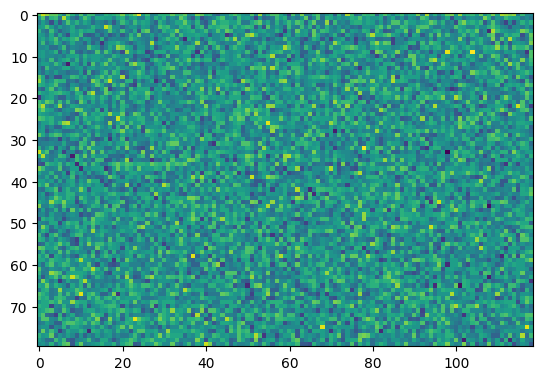

In [9]:
print(h5_f4['Acquisition2']['ImageData']['Image'].shape)
im2 = np.squeeze(h5_f4['Acquisition2']['ImageData']['Image'])
plt.imshow(im2[200,:,:])

In [10]:
dataset = im2.astype(np.float64)
print(dataset.shape)
d1, d2, d3 = dataset.shape
dataset = dataset.reshape(d1, d2*d3)

(1024, 80, 119)


In [11]:
y = torch.from_numpy(np.array(dataset.T))[:, None]
y = torch.nn.functional.avg_pool1d(y, 1, 1).squeeze().numpy()
print(y.shape)
_, s1 = y.shape

(9520, 1024)


In [12]:
y = y.reshape(d2, d3, s1)

In [13]:
hdata = y
hdata = hdata.astype(np.float64)

In [14]:
x=np.linspace(162.17, 1033.31, 1024) #128
wavelength = x

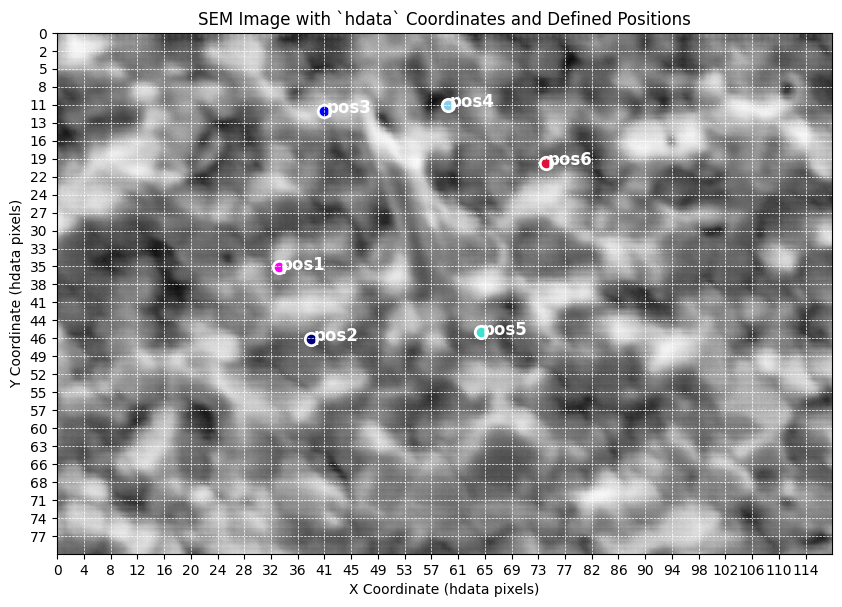

In [15]:
# Assuming im1 is the SEM image and hdata is the CL data
# Extracting dimensions directly from im1 and hdata

sem_shape = im1.shape  # SEM image shape
hdata_shape = hdata.shape  # CL map (hdata) shape

# Calculate the scaling factors based on the dimensions of SEM and hdata
scale_x = sem_shape[1] / hdata_shape[1]  # Scaling factor for width
scale_y = sem_shape[0] / hdata_shape[0]  # Scaling factor for height

# Define positions in hdata coordinates (example coordinates)
positions_hdata = {
    'pos1': [34, 36],  # Example position in hdata coordinates
    'pos2': [39, 47],   # Example position in hdata coordinates
    'pos3': [41, 12],  # Example position in hdata coordinates
    'pos4': [60, 11],  # Example position in hdata coordinates
    'pos5': [65, 46],  # Example position in hdata coordinates
    'pos6': [75, 20],  # Example position in hdata coordinates
}

# Convert hdata coordinates to SEM image coordinates for plotting
positions_sem = {
    key: (pos[0] * scale_x, pos[1] * scale_y)
    for key, pos in positions_hdata.items()
}

# Plot SEM image with grid and `hdata` coordinates on axes
fig, ax = plt.subplots(figsize=(10, 10))

# Display the SEM image
ax.imshow(im1, cmap='Greys_r')

# Adjust the ticks to reflect `hdata` coordinates
xticks = np.linspace(0, sem_shape[1], num=30)  # 30 tick marks across the x-axis
yticks = np.linspace(0, sem_shape[0], num=30)  # 30 tick marks across the y-axis
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels((xticks / scale_x).astype(int))  # Convert to `hdata` coordinates
ax.set_yticklabels((yticks / scale_y).astype(int))  # Convert to `hdata` coordinates

# Add grid and coordinates
ax.grid(True, color='white', linestyle='--', linewidth=0.5)
ax.set_xlabel('X Coordinate (hdata pixels)')
ax.set_ylabel('Y Coordinate (hdata pixels)')

# Plot the converted positions on the SEM image
colors = ['magenta', 'navy', 'blue', 'skyblue', 'turquoise', 'crimson']
for i, (label, pos) in enumerate(positions_sem.items()):
    ax.scatter(*pos, c=colors[i], marker='o', edgecolor='white', linewidth=2, s=80)
    ax.text(pos[0] + 5, pos[1] + 5, f'{label}', color='white', fontsize=12, weight='bold')

ax.set_title('SEM Image with `hdata` Coordinates and Defined Positions')

plt.show()


In [16]:
# Function to find the slice corresponding to a given wavelength
def find_slice_for_wavelength(wavelength_input):
    # Constants
    min_wavelength = 162.17
    max_wavelength = 1033.31
    num_slices = 1024

    # Scaling factor to convert wavelength to slice
    slice_scaling_factor = (max_wavelength - min_wavelength) / (num_slices - 1)

    # Find the slice index
    slice_index = int((wavelength_input - min_wavelength) / slice_scaling_factor)

    # Ensure the slice index is within bounds
    if slice_index < 0 or slice_index >= num_slices:
        return None  # Return None if the wavelength is outside the valid range
    return slice_index

# Example usage: find slice for a given wavelength (e.g., 750 nm)
example_wavelength = 773
slice_for_wavelength = find_slice_for_wavelength(example_wavelength)

slice_for_wavelength

717

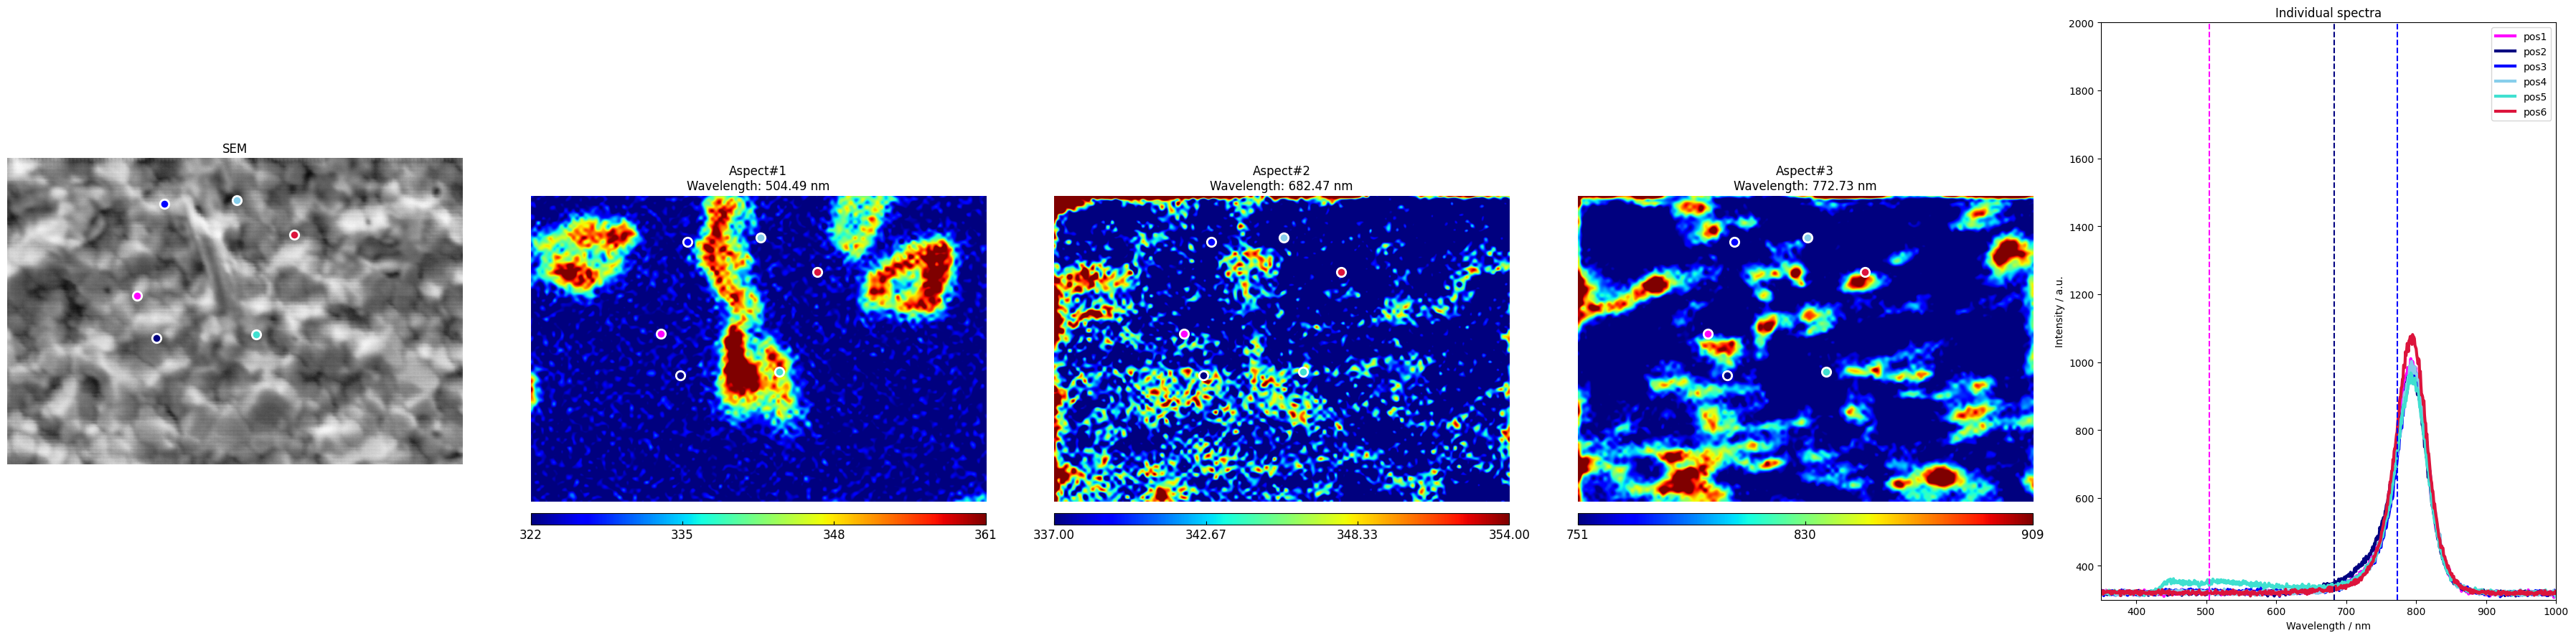

Slice 402 corresponds to wavelength: 504.49 nm
Slice 611 corresponds to wavelength: 682.47 nm
Slice 717 corresponds to wavelength: 772.73 nm


In [17]:
# Assuming positions are adjusted for the SEM image scale
positions = {
  'pos1': [34, 36],  # Example position in hdata coordinates
    'pos2': [39, 47],   # Example position in hdata coordinates
    'pos3': [41, 12],  # Example position in hdata coordinates
    'pos4': [60, 11],  # Example position in hdata coordinates
    'pos5': [65, 46],  # Example position in hdata coordinates
    'pos6': [75, 20],  # Example position in hdata coordinates
}

# Define slices corresponding to different aspects
slices = [402, 611, 717]

# Calculate scaling factors based on SEM and CL map dimensions
scale_x = im1.shape[1] / hdata.shape[1]  # Width scaling factor
scale_y = im1.shape[0] / hdata.shape[0]  # Height scaling factor

# Rescale CL maps to match SEM image dimensions and calculate vmin and vmax automatically
rescaled_cl_maps = []
for s in slices:
    rescaled_map = zoom(hdata[..., s], (scale_y, scale_x))
    vmin = np.floor(np.percentile(rescaled_map, 50))  # Using a higher percentile for vmin, floored to whole number
    vmax = np.ceil(np.percentile(rescaled_map, 98))  # Using a lower percentile for vmax, ceiled to whole number
    rescaled_cl_maps.append((rescaled_map, vmin, vmax))

# Plotting the SEM image and rescaled CL maps with scatter points and scale bars
fig, ax = plt.subplots(1, 5, figsize=(36, 9))  # Adjusted figsize to make CL maps larger and match the scale bars

# Plot SEM image without labeled positions
ax[0].imshow(im1, cmap='Greys_r')
colors = ['magenta', 'navy', 'blue', 'skyblue', 'turquoise', 'crimson']
for i, (label, pos) in enumerate(positions.items()):
    scaled_pos = np.array(pos) * [scale_x, scale_y]
    ax[0].scatter(*scaled_pos, c=colors[i], marker='o', edgecolor='white', linewidth=2, s=80)
ax[0].set_title('SEM')
ax[0].axis('off')

# Define wavelength range
wavelength = np.linspace(162.17, 1033.31, 1024)

# Plot the rescaled CL maps with scatter points and scale bars
for i, (rescaled_map, vmin, vmax) in enumerate(rescaled_cl_maps):
    im = ax[i+1].imshow(rescaled_map, cmap='jet', origin="upper", vmin=vmin, vmax=vmax)
    for pos, color in zip(positions.values(), colors):
        ax[i+1].scatter(pos[0]*scale_x, pos[1]*scale_y, c=color, marker='o', edgecolor='white', linewidth=2, s=80)
    wavelength_value = wavelength[slices[i]]
    ax[i+1].set_title(f'Aspect#{i+1}\nWavelength: {wavelength_value:.2f} nm')
    ax[i+1].axis('off')

    # Adjust the number of ticks for better readability
    num_ticks = 4 if i != 2 else 3  # Reduce the number of ticks for the third aspect
    cbar = plt.colorbar(im, ax=ax[i+1], aspect=40, orientation='horizontal', pad=0.02)
    cbar.set_ticks(np.linspace(vmin, vmax, num_ticks))  # Set ticks as whole numbers and reduce their number
    cbar.ax.tick_params(axis='x', direction='in', labelsize=12)

# Plot the individual spectra with the wavelength range on the last axis
ax[4].clear()  # Ensure no background is plotted
for label, pos, color in zip(positions.keys(), positions.values(), colors):
    ax[4].plot(wavelength, hdata[pos[1], pos[0], :], linewidth=3, c=color, label=label)

# Add vertical lines at the corresponding wavelengths for the slices
for i, s in enumerate(slices):
    ax[4].axvline(x=wavelength[s], linestyle='--', c=colors[i])

ax[4].set_title('Individual spectra')
ax[4].set_xlabel('Wavelength / nm')
ax[4].set_ylabel('Intensity / a.u.')
ax[4].set_xlim(350, 1000)
ax[4].set_ylim(300, 2000)
ax[4].legend(loc='upper right')

plt.tight_layout()
plt.show()

for i, s in enumerate(slices):
    wavelength_s = wavelength[s]
    print(f'Slice {s} corresponds to wavelength: {wavelength_s:.2f} nm')

Depending on the data sets, there will be several phases presented that can be roughly identified based on peak positions. We see some positions have more than one phase present at a time where as some may only have a single peak. Let's try clustering on it.

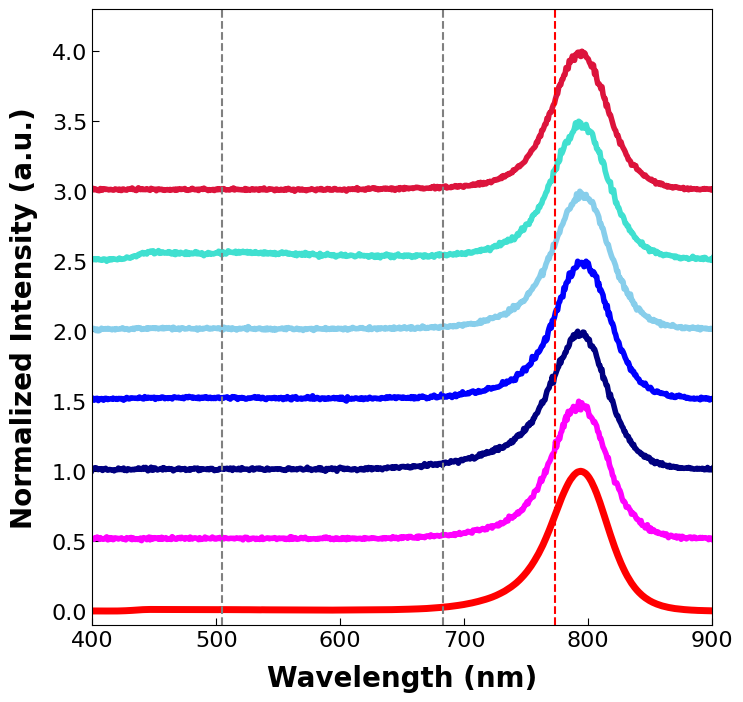

In [18]:
hdata_s = hdata.mean(axis=(0, 1))

normalized_spectra = {}
for label, pos in positions.items():
    spectrum = hdata[pos[1], pos[0], :]
    normalized_spectra[label] = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))


plt.figure(figsize=(8, 8))  # Increase figure size for better visibility
plt.plot(wavelength, (hdata_s - np.min(hdata_s)) / (np.max(hdata_s) - np.min(hdata_s)), c='red', linewidth=5, label='Mean Spectrum')


colors = ['magenta', 'navy', 'blue', 'skyblue', 'turquoise', 'crimson']
offset = 0.5  # Increase the offset to avoid overlap

for i, (label, spectrum) in enumerate(normalized_spectra.items()):
    plt.plot(wavelength, spectrum + offset * (i + 1), c=colors[i], linewidth=4, label=label)

plt.axvline(x=505, linestyle='--', c='gray', label='505 nm')
plt.axvline(x=683, linestyle='--', c='gray', label='405 nm')
plt.axvline(x=773, linestyle='--', c='red', label='687 nm')

plt.xlabel('Wavelength (nm)', fontsize=20, labelpad=10, fontweight='bold')
plt.ylabel('Normalized Intensity (a.u.)', fontsize=20, labelpad=10, fontweight='bold')
plt.tick_params(axis='x', length=5, labelsize=16, direction='in')
plt.tick_params(axis='y', length=5, labelsize=16, direction='in')
plt.xlim(400, 900)
plt.ylim(-0.1, offset * (len(positions) + 2) + 0.3)  # Adjust ylim to match the increased offset
#plt.legend(fontsize=12, loc='upper right')

plt.show()

## Manual segmentation for comparison

Let's explore treshold based segmentation. Note that these regions are overlapping, so here one pixel can belong to more then one class.

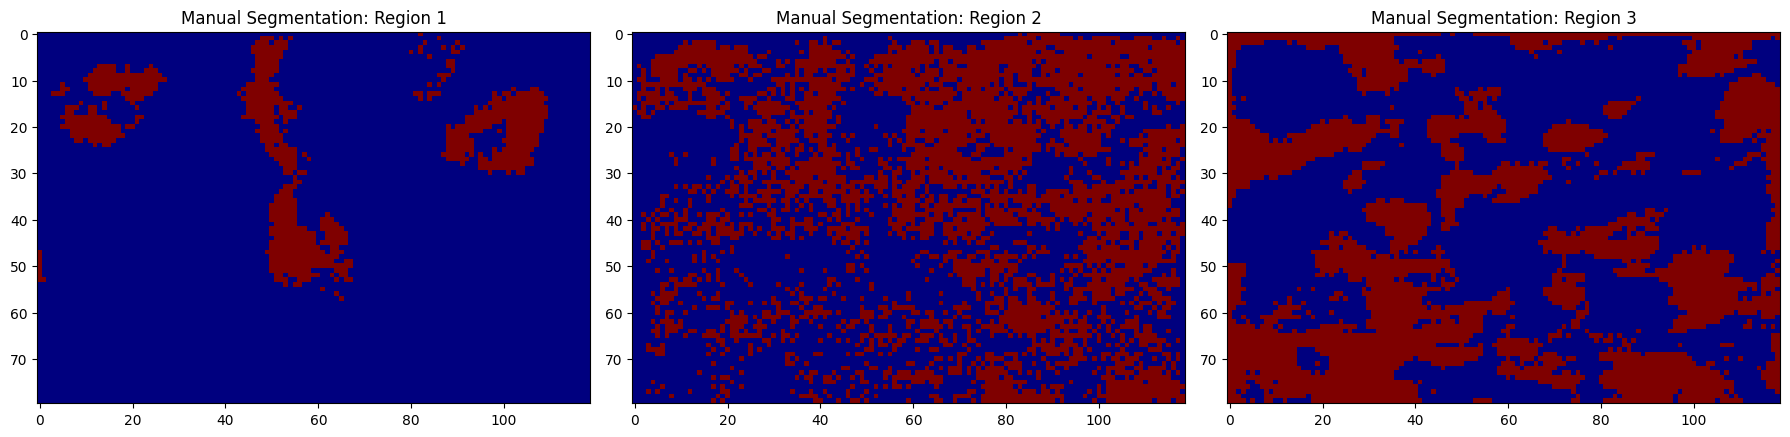

In [19]:
# Assuming slices and hdata are already loaded
s1, s2, s3 = 402, 611, 717

# Extract individual slice data
im_s1 = hdata[..., s1]
im_s2 = hdata[..., s2]
im_s3 = hdata[..., s3]

# Determine thresholds dynamically based on percentile or other criteria
threshold_s1 = np.percentile(im_s1, 90)  # For phase 1
threshold_s2 = np.percentile(im_s2, 50)  # For phase 2
threshold_s3 = np.percentile(im_s3, 60)  # For phase 3

# Apply manual segmentation based on calculated thresholds
im_s1cut = im_s1 > threshold_s1
im_s2cut = im_s2 < threshold_s2
im_s3cut = im_s3 > threshold_s3

# Reshape for visualization
h, w = hdata.shape[:2]
im_s1cut_reshaped = im_s1cut.reshape(h, w)
im_s2cut_reshaped = im_s2cut.reshape(h, w)
im_s3cut_reshaped = im_s3cut.reshape(h, w)

# Plot manual segmentation
_, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(im_s1cut_reshaped, origin="upper", cmap="jet")
ax[0].set_title("Manual Segmentation: Region 1")

ax[1].imshow(im_s2cut_reshaped, origin="upper", cmap="jet")
ax[1].set_title("Manual Segmentation: Region 2")

ax[2].imshow(im_s3cut_reshaped, origin="upper", cmap="jet")
ax[2].set_title("Manual Segmentation: Region 3")

plt.tight_layout()
plt.show()

# Store manual segmentation labels for ground truth (combine regions into one label map)
ground_truth = np.zeros_like(im_s1cut_reshaped, dtype=int)
ground_truth[im_s1cut_reshaped] = 1  # Label for Region 1
ground_truth[im_s2cut_reshaped] = 2  # Label for Region 2
ground_truth[im_s3cut_reshaped] = 3  # Label for Region 3

## Problem II.1. Clustering of spectral data

Problem II.1.1:
- Realize a set of classifiers for the spectral data
- For each classifier, plot the label map and the cluster centroids
- Compare the quality of clustering to the physical segmentation labels above (note that these are not mutually exclusive).


Problem II.1.2:
- The cluster labels will be different between different classifiers
- Suggest an approach to compare the classification results between different methods

Problem II.1.3:
- Explore the dimensionality reduction of the data using the PCA
- Visualize the loading maps and components
- Plot the data in the PCA space and visualize the distribution of the physics based segmentation labels
- Cluster the data in the 2D PCA space
- Compare the resultant labels and the physics based segmentation labels.

## Problem II.2: Supervised learning

Here, we will need to define the class labels. Since we do not have independent access to them, let's use the results of k-means clustering that you have done above as the ground truth labels.

In [20]:
# Assuming 'kmeans_labels' are the clustering labels from KMeans
'''
spectral_labels_reshaped = kmeans_labels.reshape(h, w)  # If you're using KMeans for spectral clustering

# Flatten the CL data (hdata) for supervised learning
h, w, spectra_size = hdata.shape
spectra_all_points = hdata.reshape(-1, spectra_size)

# Flatten the clustering labels for supervised learning
labels_all_points = spectral_labels_reshaped.reshape(-1)
'''

"\nspectral_labels_reshaped = kmeans_labels.reshape(h, w)  # If you're using KMeans for spectral clustering\n\n# Flatten the CL data (hdata) for supervised learning\nh, w, spectra_size = hdata.shape\nspectra_all_points = hdata.reshape(-1, spectra_size)\n\n# Flatten the clustering labels for supervised learning\nlabels_all_points = spectral_labels_reshaped.reshape(-1)\n"

Problem II.2.1:
- Split the data in the train/test sets, assuming 10% for training and 90% for testing
- Realize the logistic, perceptron, kNN, and SVM classifiers
- Plot the class maps
- Construct the ROC curves

Problem II.2.2:
- Explore the effect of the decision treshold parameter for the logistic classifier
- Plot class maps for tresholds 0.01, 0.1, 0.5, 0.9, 0.99

Problem II.2.3:
- Based on the class maps, suggest criteria on how "good" maps can be identified.

# III. Discovering phases and ferroelectric domains

**Lets Install some usefull packages**

In [21]:
# Installing Kornia and pyroved
!pip install -q kornia atomai git+https://github.com/ziatdinovmax/pyroVED@main
!pip install colorspacious
!pip install wget

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 118.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=124f608a6a20ac1d5c400df126b8fdc96b71b099c459b9679b1d0cab62e2a748
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget


**Import libraries**

In [22]:
from atomai import utils
from atomai import stat as atomstat
import atomai as aoi

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

In [25]:
import gdown
import h5py
import wget
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
import matplotlib.patches as patches

<span style="color: blue; font-size: 18px;"><strong>Download Dataset</strong></span>

This data set is the collection of high resolution electron microscopy images of the ferroelectric BiFeO3 doped with Sm. The samples were prepared as combinatorial library by Prof. Ichiro Takeuchi group (University of Maryland). The STEM data was taken and physics based analysis was performed by Dr. Chris Nelson (Oak Ridge). Data sharing enables downstream applications and is common in many scientific domains (structural data, thermodynamics, genomics, theoretical computational databases). It is an emerging trend in areas such as microscopy. Note that making data available is a part of FAIR principles and is now mandated by funding agencies in US (NSF, DOE, etc).  

Now, we have access to the SmBFO STEM image with Sm = 0, 7, 10, 13% compositions. Note that Sm = 0 composition is the pure rhombohedral ferroelectric, whereas high Sm concentrations are orthorhombic non-ferroelectric material. Since rhombohedral and orthorhombic phases are crystallograhically incompartible, the phases with intermediate Sm concentrations have to acocmodate this structural mismatch by forming complex nanoscale structures. In macroscopic scattering data, they can show period doubling, low-symmetry phases, etc. - however, their true nanoscale strucutre is understood only poorly. These morphotropic systems also have interesting macroscopic properties such as enhanced dielectric and electromechnical properties. So, let's dive in into atomic world of these systems!

In [26]:
model_files = ['Sm_0_1_HAADF.h5',
               'Sm_0_1_UCParameterization.h5',
               'Sm_7_2_HAADF.h5',
               'Sm_7_2_UCParameterization.h5',
               'Sm_10_1_HAADF.h5',
               'Sm_10_1_UCParameterization.h5',
               'Sm_13_0_HAADF.h5',
               'Sm_13_0_UCParameterization.h5',
               'Sm_20_0_HAADF.h5',
               'Sm_20_0_UCParameterization.h5']

for model_file in model_files:
  print(model_file)
  wget.download("https://zenodo.org/record/4555979/files/"+model_file+"?download=1", out=model_file)

Sm_0_1_HAADF.h5
Sm_0_1_UCParameterization.h5
Sm_7_2_HAADF.h5
Sm_7_2_UCParameterization.h5
Sm_10_1_HAADF.h5
Sm_10_1_UCParameterization.h5
Sm_13_0_HAADF.h5
Sm_13_0_UCParameterization.h5
Sm_20_0_HAADF.h5
Sm_20_0_UCParameterization.h5


In [27]:
#list files
filedir = '/content'
[f for f in os.listdir(filedir)]

['.config',
 'Sm_10_1_HAADF.h5',
 'Sm_13_0_HAADF.h5',
 '0220415_D48_30kx_5kV_32pA_LV_400ms_119X80_40nm_2_corrected.h5',
 'Sm_0_1_HAADF.h5',
 'Sm_7_2_HAADF.h5',
 'Sm_20_0_HAADF.h5',
 '0220418_D50_30kx_5kV_32pA_LV_400ms_119X80_40nm_1MHz_8g_re_corrected (1).h5',
 'Sm_7_2_UCParameterization.h5',
 'Sm_13_0_UCParameterization.h5',
 '0220415_D45_30kx_5kV_32pA_LV_200ms_119X80_40nm_1_corrected.h5',
 'Sm_0_1_UCParameterization.h5',
 'Sm_20_0_UCParameterization.h5',
 'Sm_10_1_UCParameterization.h5',
 '20220510_D17_30kx_5kV_32pA_LV_400ms_119X80_40nm_1MHz_3g_corrected.h5',
 'sample_data']

In [28]:
#image files
composition_tags = [0,7,10,13,20]    #Sm composition %


img_filename = ['Sm_0_1_HAADF.h5',
                'Sm_7_2_HAADF.h5',
                'Sm_10_1_HAADF.h5',
                'Sm_13_0_HAADF.h5',
                'Sm_20_0_HAADF.h5',]

imnum = len(img_filename)

#parametrization files

UCparam_filename = ['Sm_0_1_UCParameterization.h5',
                    'Sm_7_2_UCParameterization.h5',
                    'Sm_10_1_UCParameterization.h5',
                    'Sm_13_0_UCParameterization.h5',
                    'Sm_20_0_UCParameterization.h5',]

#load parameter files
UCparam = []
for x in UCparam_filename:
  print('loading parameterization file: ', os.path.join(filedir, x))
  temp = h5py.File(os.path.join(filedir, x), 'r')
  UCparam.append(temp)

#load images
imgdata = []
for x in img_filename:
  print('loading image file: ', os.path.join(filedir, x))
  temp = h5py.File(os.path.join(filedir, x), 'r')['MainImage']
  imgdata.append(temp)

print('UC parameterization:', [k for k in UCparam[0].keys()])

loading parameterization file:  /content/Sm_0_1_UCParameterization.h5
loading parameterization file:  /content/Sm_7_2_UCParameterization.h5
loading parameterization file:  /content/Sm_10_1_UCParameterization.h5
loading parameterization file:  /content/Sm_13_0_UCParameterization.h5
loading parameterization file:  /content/Sm_20_0_UCParameterization.h5
loading image file:  /content/Sm_0_1_HAADF.h5
loading image file:  /content/Sm_7_2_HAADF.h5
loading image file:  /content/Sm_10_1_HAADF.h5
loading image file:  /content/Sm_13_0_HAADF.h5
loading image file:  /content/Sm_20_0_HAADF.h5
UC parameterization: ['I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'abdelta', 'alpha', 'atmindex', 'b', 'index', 'meanuca', 'meanucb', 'nbrUC', 'xy_COM', 'xy_atms']


- In addition to the raw STEM data, the parametrization files yield the information on each unit cell within the data that we can use as a physics-based comparison to ML analyses. For example, I1-5 are intensity of atomic columns, Vol is unit cell volume, Pxy are polarization components, and so on.
- Note that since the physics of these systems is not known exactly (that is why we are studying them!), ML can discover new phenomena that were not acocunted for in physics-based descriptors.
- Look though the code below and try to follow how we store and organize the data.  

In [29]:
#function maps x,y grid positions into a matrix data format
def map2grid(inab, inVal):

  default_val = np.nan
  abrng = [int(np.min(inab[:,0])), int(np.max(inab[:,0])), int(np.min(inab[:,1])), int(np.max(inab[:,1]))]
  abind = inab
  abind[:,0] -= abrng[0]
  abind[:,1] -= abrng[2]
  Valgrid = np.empty((abrng[1]-abrng[0]+1,abrng[3]-abrng[2]+1))
  Valgrid[:] = default_val
  Valgrid[abind[:,0].astype(int),abind[:,1].astype(int)]=inVal[:]
  return Valgrid, abrng

In [30]:
def plot_polarization_vectors(k):

    # Prepare vector components and positions
    X = k['ab_x'].ravel()
    Y = k['ab_y'].ravel()
    U = k['ab_Px'].ravel()
    V = k['ab_Py'].ravel()

    # Rotate coordinates 90 degrees counter-clockwise
    X_rot = -Y
    Y_rot = X

    # Invert y-axis
    Y_rot = -Y_rot

    # Rotate vector components
    U_rot = -V
    V_rot = U

    # Invert y-axis component of vectors
    V_rot = -V_rot

    # Compute magnitude and direction of the polarization vectors
    # Compute magnitude and direction of the polarization vectors
    Pmag = np.sqrt(U**2 + V**2)
    Pdir = np.arctan2(V, U)

    # Normalize magnitude for color scaling (clip at 90th percentile to avoid outliers)
    Pmag_norm = np.clip(Pmag / np.nanpercentile(Pmag, 90), 0, 1)

    # Define the colormap for mapping the direction and magnitude
    # Since 'papuc' may not be available, we'll use a built-in colormap

    # Normalize direction to [0, 1] for colormap mapping
    norm = Normalize(vmin=-np.pi, vmax=np.pi)
    cmap = cm.hsv  # Using HSV colormap to represent directions

    # Map direction to colors
    cP = cmap(norm(Pdir))

    # Alternatively, adjust colors based on magnitude if desired
    # For this simple example, we'll just use direction for color
    return Y, X, U, V, cP

In [31]:
SBFOdata = []     #this will be the output list of dictionaries for each dataset

for i in np.arange(imnum):
  temp_dict = {'Index': i}
  temp_dict['Composition'] = composition_tags[i]
  temp_dict['Image'] = imgdata[i]
  temp_dict['Filename'] = img_filename[i]

  for k in UCparam[i].keys():       #add labels for UC parameterization
    temp_dict[k] = UCparam[i][k][()]

  #select values mapped to ab grid
  temp_dict['ab_a'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['ab'][()].T[:,0])[0]       #a array
  temp_dict['ab_b'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['ab'][()].T[:,1])[0]       #b array
  temp_dict['ab_x'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['xy_COM'][()].T[:,0])[0]   #x array
  temp_dict['ab_y'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['xy_COM'][()].T[:,1])[0]   #y array
  temp_dict['ab_Px'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['Pxy'][0])[0]             #Px array
  temp_dict['ab_Py'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['Pxy'][1])[0]        #Py array
  temp_dict['Vol'] = map2grid(UCparam[i]['ab'][()].T, UCparam[i]['Vol'])[0]     #Vol array

  SBFOdata.append(temp_dict)

Explore the structure of the SBFOdata object. Are the comments in the code sufficient to interpret what are the individual elements in it?

In [32]:
SBFOdata[1].keys()

dict_keys(['Index', 'Composition', 'Image', 'Filename', 'I1', 'I2', 'I3', 'I4', 'I5', 'NCOM', 'PCOM', 'Pxy', 'Vol', 'a', 'ab', 'adelta', 'alpha', 'atmindex', 'b', 'bdelta', 'index', 'meanuca', 'meanucb', 'nbrUC', 'xy_COM', 'xy_atms', 'ab_a', 'ab_b', 'ab_x', 'ab_y', 'ab_Px', 'ab_Py'])

In [33]:
SBFOdata[1]['ab_a'].shape

(166, 155)

Now, let's visualize the images and corresponding distributions of polarization components Px, Py, and unit cell volume Vol

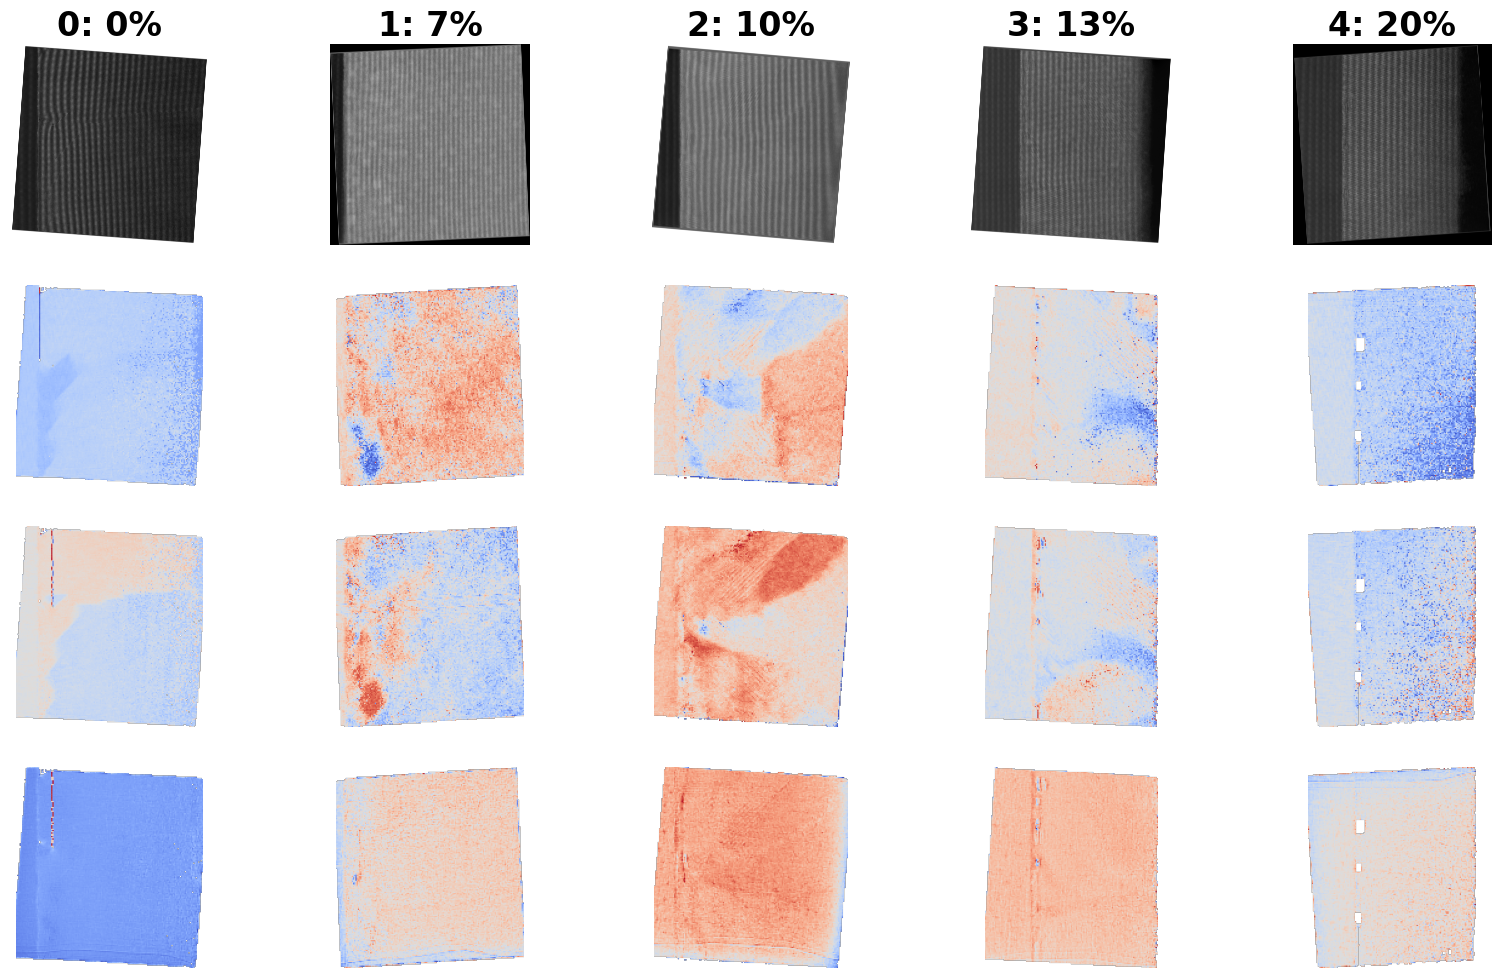

In [34]:
fig, ax = plt.subplots(nrows=4, ncols=len(SBFOdata), figsize=(4*len(SBFOdata), 4*3), dpi=100)
for i, k in enumerate(SBFOdata):
  #Image
  ax[0,i].imshow(k['Image'], origin='upper', cmap='gray')
  ax[0,i].set_title(str(k['Index'])+': '+str(k['Composition'])+'%', fontsize = 24, fontweight = "bold")
  ax[0,i].set_axis_off()
  #Px
  ax[1,i].imshow(k['ab_Px'], origin='upper', cmap='coolwarm')
  ax[1,i].set_axis_off()
  #Py
  ax[2,i].imshow(k['ab_Py'], origin='upper', cmap='coolwarm')
  ax[2,i].set_axis_off()

  # Vol (added row to display Vol)
  ax[3, i].imshow(k['Vol'], origin='upper', cmap='coolwarm')
  ax[3, i].set_axis_off()

As you can see, for low Sm concentrations the olarization maps show clear ordered ferroelectric domains.On increasing Sm concentration, they become more disordered and then disappear for 20% Sm. Also note that unit cell volume map shows (some) variation between material and substrate, does not show variations associated with the domains, and also shows smooth changes across the image plane. The latter are associated with non-ideality of the microscope (the mis-tilt effects).

You can also note the missing regions on the last image. These correspond to the regions that contained growth defects and were removed during the curation of the data set.

## **Problem III.1:** Classification of ferroic domains

Now, let's experiment with the practical problem.
- Let's assume that we **know** the phase/ferroic orientation in several regions of the material. These will be our labels.
- Given these labels, we would like to classify the remaining parts of the image.
- However, for the time being we also **do not** have any information about atomic positions, physical order parameter fields, etc. All we have access to is the image data. Can we classify the regions in the image given small amount of known labels?

Let's do it for pure BFO (with well defined domains), corresponding to imgdata[0]. We will use the sliding window approach, representing the image as a collection of image patches of certain size taken from the grid of points. Explore the code below to identify how this is done.


In [35]:
img_array = np.array(imgdata[0])
scaler = preprocessing.StandardScaler().fit(img_array)
scaler.mean_
scaler.scale_
X_scaled = scaler.transform(img_array)

window_size = 50
step_size = 6

# Generate a grid of coordinates based on the step size
coordinates = aoi.utils.get_coord_grid(X_scaled, step_size)

# Extract the coordinates from the first element (assuming it's the desired set)
coords = coordinates[0]

# Extract subimages, centers of mass, and frame numbers based on the generated grid
imstack_grid, com_grid, frames_grid = aoi.utils.extract_subimages(X_scaled, coords, window_size)

# Output the shape of the extracted image stack
print(imstack_grid.shape)
print(com_grid.shape)
print(frames_grid.shape)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


(444189, 50, 50, 1)
(444189, 2)
(444189,)


Below, we
- Create array of the same length as coordinate and patches filled by zeros
- Identify spatial regions that are substrate, domain 1, 2, and 3
- For coordinates that fall within these, we change labels from 0 to 1,2,3 respectively.

With that, we will have coordinate array, patch array, and label array where 1,2,3 are known labels and 0 are unknown labels. And they can experiment with window sizes and all arrays will be recalculated.


In [36]:
# Initialize a label array of zeros
label_array = np.zeros(len(com_grid), dtype=int)

In [37]:
# Define spatial regions (
substrate_region = [3000, 3150, 400, 550]  # Substrate region
domain1_region = [2000, 2150, 1000, 1150]  # Domain 1 region
domain2_region = [3000, 3150, 2000, 2150]  # Domain 2 region
domain3_region = [1000, 1150, 2000, 2150]  # Domain 3 region

In [38]:
# Ensure that com_grid and label_array are of the same size before processing
if len(label_array) != len(com_grid):
    raise ValueError("label_array and com_grid must have the same length!")

# Assign labels based on the coordinates falling within the regions
for i, (x, y) in enumerate(com_grid):
    if substrate_region[0] <= x <= substrate_region[1] and substrate_region[2] <= y <= substrate_region[3]:
        label_array[i] = 1  # Substrate
    elif domain1_region[0] <= x <= domain1_region[1] and domain1_region[2] <= y <= domain1_region[3]:
        label_array[i] = 2  # Domain 1
    elif domain2_region[0] <= x <= domain2_region[1] and domain2_region[2] <= y <= domain2_region[3]:
        label_array[i] = 3  # Domain 2
    elif domain3_region[0] <= x <= domain3_region[1] and domain3_region[2] <= y <= domain3_region[3]:
        label_array[i] = 4  # Domain 3

# Output the label array and its distribution to check the correctness
print("Label array:", label_array)
print("Distribution of labels:", np.unique(label_array, return_counts=True))

# Ensure that label_array, com_grid, and imstack_grid are aligned in size
print("Coordinates shape (com_grid):", com_grid.shape)
print("Image stack shape (imstack_grid):", imstack_grid.shape)
print("Label array shape:", label_array.shape)

Label array: [0 0 0 ... 0 0 0]
Distribution of labels: (array([0, 1, 2, 3, 4]), array([441639,    650,    625,    650,    625]))
Coordinates shape (com_grid): (444189, 2)
Image stack shape (imstack_grid): (444189, 50, 50, 1)
Label array shape: (444189,)


This is our label array. The region 0 are unknown, the regions 1,2,3, and 4 are known labels.

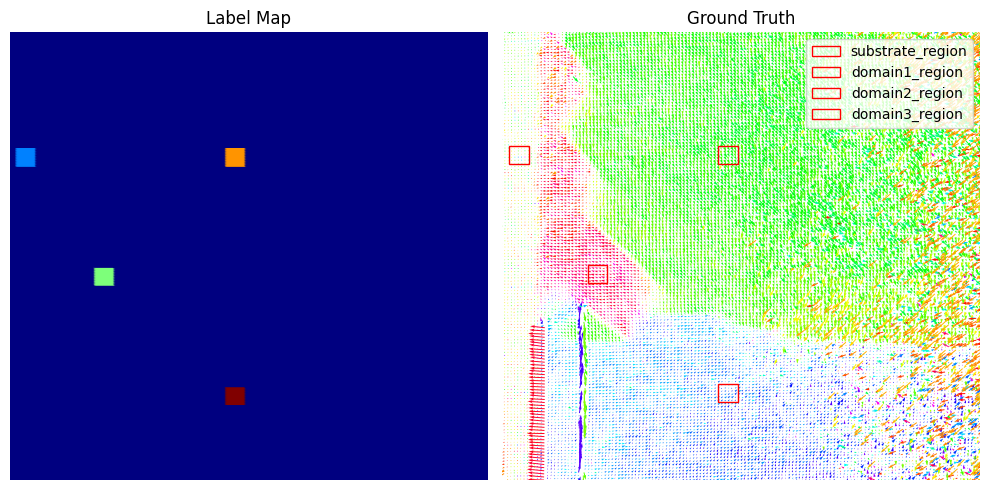

In [39]:
# Example regions to mark on the plot
regions = {
    'substrate_region': (400, 3000, 150, 150),
    'domain1_region': (2000, 1000, 150, 150),
    'domain2_region': (2000, 3000, 150, 150),
    'domain3_region': (1000, 2000, 150, 150)
}

# Assuming 'main' and 'SBFOdata' are defined
main = [350, 4000, 350, 4100]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Visualize the label map on the first subplot
axes[0].scatter(com_grid[:, 1], com_grid[:, 0], c=label_array, cmap='jet', s=10)
axes[0].set_title('Label Map')
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].invert_yaxis()
axes[0].axis("off")
axes[0].set_xlim(main[0], main[1])
axes[0].set_ylim(main[2], main[3])

# Plot the polarization vectors on the second subplot
k = SBFOdata[0]  # Assuming SBFOdata is well defined with necessary keys
Y, X, U, V, cP = plot_polarization_vectors(k)
axes[1].quiver(Y, X, U, V, color=cP, scale=0.1, angles='xy', scale_units='xy', width=0.002)
axes[1].set_title('Ground Truth')
axes[1].set_xlim(main[0], main[1])
axes[1].set_ylim(main[2], main[3])
axes[1].axis("off")

# Add regions as rectangles on the second subplot
for region_name, (x, y, width, height) in regions.items():
    # Create a rectangle at each region
    rect = Rectangle((x, y), width, height, linewidth=1, edgecolor='r', facecolor='none', label=region_name)
    axes[1].add_patch(rect)

# Optionally, add a legend if needed
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


In [40]:
# Split the labeled and unlabeled data
labeled_indices = np.where(label_array > 0)[0]  # Indices where labels are known
unlabeled_indices = np.where(label_array == 0)[0]  # Indices where labels are unknown

# Prepare the training data (patches and labels)
X_train = imstack_grid[labeled_indices]  # Known patches (train data)
y_train = label_array[labeled_indices]  # Corresponding labels (1, 2, 3)

# Prepare the test data (patches without labels)
X_test = imstack_grid[unlabeled_indices]  # Patches for unknown labels (test data)
# Check if there are any unknown labels (0s) in the label_array
print(f"Number of unlabeled data points: {np.sum(label_array == 0)}")

# Flatten patches (if needed) for RandomForest input
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # Flatten for training
X_test_flat = X_test.reshape(X_test.shape[0], -1)  # Flatten for testing

print(f"Number of unlabeled data points: {np.sum(label_array == 1)}")

Number of unlabeled data points: 441639
Number of unlabeled data points: 650


Problem III.1.1:
- define several classifiers
- classify the unknown points
- make the map of the class labels for each classifier
- create average class labels and uncertainty map based on multiple classifiers.

Problem II.1.2:
- Choose one classifier
- Explore the effect of the window size on classification

Problem II.1.3:
- For the regions outside of the labeled ones, we do not have access to the ground truth data (so we can define confusion matrix/ROC/AUC only **within** labeled regions)
- However, we do have access to ground truth data (Px,Py, Vol) and all other descriptors
- Suggest a startegy to estimate the quality of classification if the ground truth labels are not available, but we have access to (Px,Py, Vol). Realize it for one classifier.

## **Problem III.2:** Unsupervised exploration

Now, let's explore one of the intermediate concentrations of Sm images using sliding window approach. Let's proceed as following:
- Import one of the images for the intermediate concentrations that show the presence of ferroelectric and ordered phases. Choose an image!
- Create a standard data sets, meaning coordinate array and matching array of patches. Here we add additional degree of freedom by allowing the window to be rectangular, (w1,w2).
- Let's  explore clustering given the patches, and explore window size effects

Custom function for chosing rectangular windows

In [41]:
def custom_subimages(imgdata, step_size, window_size):
    # Generate coordinates based on step size
    height, width = imgdata.shape[:2]
    x_coords = np.arange(0, height - window_size[0] + 1, step_size)
    y_coords = np.arange(0, width - window_size[1] + 1, step_size)
    coordinates = [(x, y) for x in x_coords for y in y_coords]

    # Extract subimages of the specified window size
    half_height = window_size[0] // 2
    half_width = window_size[1] // 2
    subimages_target = []
    coms_target = []
    removed_due_to_size = 0
    removed_due_to_nans = 0

    for coord in coordinates:
        cx, cy = coord
        top = max(cx - half_height, 0)
        bottom = min(cx + half_height, height)
        left = max(cy - half_width, 0)
        right = min(cy + half_width, width)

        subimage = imgdata[top:bottom, left:right]

        if subimage.shape != tuple(window_size):
            removed_due_to_size += 1
        elif np.isnan(subimage).any():
            removed_due_to_nans += 1
        else:
            subimages_target.append(subimage)
            coms_target.append(coord)

    print("Number of subimages removed due to size mismatch:", removed_due_to_size)
    print("Number of subimages removed due to NaNs:", removed_due_to_nans)

    return np.array(subimages_target), np.array(coms_target)

In [42]:
window_size = (12, 20)
step_size = 12

imstack_grid, com_grid = custom_subimages(imgdata[0], step_size, window_size)

print(imstack_grid.shape)
print(com_grid.shape)

Number of subimages removed due to size mismatch: 736
Number of subimages removed due to NaNs: 21977
(113073, 12, 20)
(113073, 2)


Problem III.2.1:
- Select image and window size
- Cluster the image patches
- Visualize the labels map
- Estimate the required number of clusters


Problem II.2.2:
- Let's assume that we want to compare multiple clustering approaches. The problem is that cluster labels are assigned randomly, meaning (0,1,2) in one clustering method will not match the labels from other method
- Suggest and realize approach to align the labels between different clustering methods

Problem III.2.3:
- Realize 3 different clustering methods of the data
- Align the labels
- Plot the average and uncertainty maps

# IV. Predicting bulk modulus: features and training-data selection

Use matminer Magpie composition descriptors to predict bulk modulus (`K_VRH`, GPa) for the 1,181 materials in the elastic-properties dataset. Use Ridge regression with `alpha=10` throughout. The source data needed for this exercise are included below.

Keep one approximately 80/20 development/test split (random seed 42), grouping identical reduced formulas together. Impute missing descriptor values, remove constant or numerically near-constant descriptors (variance ≤ $10^{-10}$ in original descriptor units), and standardize using each training partition only. For Tasks 4–5, use all descriptors, five repeated samples per strategy, and the same held-out test set. Do not use test performance to choose features or sampling strategies.

**1. Baseline prediction.** Calculate Magpie descriptors, fit Ridge using all usable descriptors, and report test MAE, RMSE, and $R^2$. Plot predicted versus reference bulk modulus. Explain one limitation of composition-only prediction.

**2. Rank the descriptors.** Rank the descriptors by the absolute coefficients of the full Ridge model fitted to standardized development inputs. Retain the top 20, plot their importance, and explain the physical meaning of the top three. Why does this ranking not establish causality?

**3. Find the best three-feature combination.** Evaluate all $\binom{20}{3}=1140$ triplets using the same five composition-grouped cross-validation folds. Select the lowest-validation-MAE triplet. Compare test performance for all descriptors, the top 20, the top three individually ranked descriptors, and the best triplet. Is the joint search substantially better? The shortlist uses development labels, so validation is a selection score; the test set supplies the final assessment.

**4. Select materials by composition.** Compare random sampling, materials with at least three elements only, materials with one or two elements only, and a balanced mixture of these groups. Use training sizes 61, 123, and 221, with five repeats. Plot full-test MAE versus size and report errors separately for both composition groups. Does specialization help locally or globally? Explain the result and propose one other composition criterion.

**5. Select materials by melting-temperature descriptor.** Rank the development materials by composition-weighted mean elemental melting temperature. Compare random sampling, sampling from the lowest third, sampling from the highest third, and approximately equal sampling from five equal-width descriptor bins. Redistribute unfilled bin quotas without duplication. Use training sizes 78, 157, and 283, with five repeats. Plot MAE versus size and compare errors in the low and high descriptor ranges. Does restricted sampling improve prediction? Explain why sorting the same complete training set would not change Ridge predictions. This descriptor is not the compound's measured melting temperature.


## Data source and reproducibility

The usual matminer download host was inaccessible during this run. These are the formula and `K_VRH` columns from the official archived matminer elastic-tensor table, with all 1,181 rows in their original order:

https://raw.githubusercontent.com/hackingmaterials/matminer/v0.4.0/matminer/datasets/elastic_tensor.csv

Original reference: de Jong et al., *Charting the complete elastic properties of inorganic crystalline compounds*, Scientific Data 2, 150009 (2015).

The embedded table makes the exercise independent of the external dataset download. Other property columns are deliberately excluded. Execution used matminer 0.10.1, pymatgen 2026.5.4, scikit-learn 1.8.0, NumPy 2.3.5, pandas 2.2.3, and matplotlib 3.10.8. Small differences can occur with other versions.


In [ ]:
%pip -q install matminer==0.10.1 scikit-learn==1.8.0 matplotlib==3.10.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 851.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━

## Starter data
Run this cell, then add your solution cells below. This table contains only the inputs and target needed for the exercise.

In [ ]:
import io
import pandas as pd
DATA_CSV = 'formula,K_VRH\nNb4CoSi,194.268884359\nAl(CoSi)2,175.449906754\nSiOs,295.077544987\nGa,49.1306700392\nSiRu2,256.768080753\nAlCo3C,234.454509647\nCdSnSb2,36.2332855036\nIr,346.322761289\nSbIr,160.280885962\nMnSbIr,131.974860422\nNa,8.73558120041\nLi,13.8322947315\nLi2SbPd,65.6266771853\nMgSbPd,80.6590789768\nMgSbPt,88.6931427228\nCo,211.575063659\nTaRh3,260.289475347\nHf3(SiCu)4,153.481403783\nZnFe3C,213.076984204\nHfRh3,219.049911869\nScCo3C,214.478806441\nZnCo3C,216.753843035\nBaF2,54.4295521673\nHf,107.972498567\nSbPt7,210.312118598\nMgCu2,94.1478259192\nTa2O5,126.318\nSb,33.1623220471\nHfSi,152.654742356\nY(AlSi)2,76.9639228911\nHfSiPt,192.145511691\nHfSiPd,169.34783933\nNbSn2,96.0166326713\nNbSiPt,214.952793253\nNbSiRh,221.400699086\nY2AlSi2,84.1434419505\nAl3Ni2,130.382765916\nAg,87.5403579133\nCuSn,76.5049886904\nY3SnC,82.3694352922\nSnSb,50.1333715597\nLiAl,49.7943883705\nSc2AlSi2,101.515756355\nHfSi2,131.919118005\nZnS,68.253065272\nVSi2,174.498090186\nScRh3C,214.967767363\nTi2C,138.937889822\nCaCd,30.5152855492\nSi3Pt2,160.933227154\nMg2SiCu3,98.1164321959\nTiFeSb,113.40134736\nGeSe,58.191710702\nCaCd2,40.289063565\nVIr3,319.664541464\nTaC,323.936233216\nScAlAu2,113.866190631\nCa3Al7Cu2,65.2176133541\nCa(Al2Cu)4,92.8605099131\nAlCrCo2,203.115171869\nAlFeCo2,187.880732162\nAl3Cu2,102.134361983\nHfAlCu2,134.711725253\nTiIr3,294.463907243\nLiAl3,64.0886202353\nMnAlPd2,141.404478825\nMnAlPt,122.912556849\nMn2AlV,184.521485556\nAl3Pd2,128.601571374\nAlPt,184.177759974\nAl3Pt2,153.487246838\nAlRe2,255.09638869\nAl2Ru,167.317248161\nSc2Al3Ru,111.94862025\nAs,42.8330650461\nY(Al2Cu)4,100.798018869\nBaO2,66.933\nMn5Si3,148.060235626\nCa3(SiIr)4,131.563643103\nVSi2,174.571650387\nCrSi2,195.428406155\nY,41.3464283085\nMo3Ir,288.168360516\nSc6FeSb2,72.0081775311\nY6FeSb2,58.8975977843\nSc2Al,70.2846905741\nAl12W,91.6750655316\nYAl,59.583134177\nYAl,64.8770714744\nY2Al,54.6187693946\nYAl3,76.3174464751\nLiAu3,98.8092526748\nMg2Au,58.4165032504\nMnAu2,123.701145334\nScAu,102.787192456\nTiAu,137.281192817\nYAu,86.388139102\nMnBe2,163.159846441\nBe2Nb3,165.10967723\nBe3Nb,154.710986148\nBe2Re,242.304358838\nBeRh,206.582759461\nScBe5,108.47114407\nTa2Be,186.817992061\nTiBe,125.896576784\nSiIr,214.868679024\nTiBe12,121.634688662\nBe2V,160.056870297\nBe2W,217.996689552\nCaHg,35.0244661788\nCaHg2,37.5310387774\nCa3Hg2,30.3792817166\nScIr,165.681249553\nCaSn3,43.3535896032\nCd2Hg,37.3512082895\nTc,300.187337173\nTiCdHg2,72.6960402398\nMgCd,43.2387467595\nNbPd3,200.077213526\nCaAl9Co2,84.5044697073\nTaCo3,146.85075593\nMgCuSn,63.1475331377\nTiCu,128.365789846\nLiF,69.88112627\nYFe5,104.762263636\nCo3Mo,260.424715726\nAl2O3,232.321\nHfMn2,192.321949544\nTiB2,253.291634054\nHfOs,229.230930365\nHfPd3,178.51656751\nHf2Pd,136.801693799\nHfPt,184.791822961\nHfPt3,232.92282956\nHfTc,191.943100431\nMgHg2,40.6277336583\nMg5Hg3,42.9959925295\nHg2Pt,83.4766763659\nScHg,75.8333814374\nMoIr3,336.958408077\nLi3Pd,36.9573682409\nLi2ZnSn,37.5784946942\nYMg2,42.8443838201\nMnZn3,87.4711856013\nLiAl2Ir,134.960007867\nNbPt2,244.360582359\nNbRu3,270.555960559\nTiRh3,230.485031535\nNbAlRu2,230.519133991\nVPd2,190.135945762\nSc2Pt,90.7379996567\nScRe2,225.991663657\nGaSb,44.6537938328\nTiSiRu,202.248801497\nYRh5,177.619679683\nScZn,75.1904306288\nScZn12,80.8823722006\nYSn3,61.9185747501\nTaTc,254.641370338\nTiTc,206.535266856\nVZn3,112.623621449\nLi2Ca,15.9849770871\nScCu,81.1563903444\nTaSb2,101.896942956\nSn,38.4897580983\nMgRh,114.636512973\nMgSc,48.418736208\nFe3Pt,177.325737886\nMnPt3,217.203794623\nLiPt,114.707017588\nTiAl2,108.174701065\nCaPd5,113.435880798\nVRh3,250.717680647\nHfSnPd,122.433850961\nHg2Rh,87.7434209598\nZnSe,58.261604019\nCdPt,136.797101368\nCaSn2Ir,76.9152590507\nCaSn2Pd,60.0073708142\nCaSn2Rh,66.0718418632\nLiSnAu,61.0796469027\nCrIr3,307.183535226\nCu3Pt,159.312639978\nNbSi2,174.577734134\nTiPt3,237.057095434\nVPt2,246.364334591\nScCd,67.0415808284\nCa(ZnSi)2,70.0251837377\nTe2O5,44.713\nBa,8.85682289679\nBe5Au,137.578070668\nCrSi2,195.535564151\nHgO,23.943\nMo3Pt,266.029101501\nTiIr,228.357481168\nCa5Sb3,36.4825683416\nVRh,233.046986865\nTiCu3,139.580066642\nAlCuPt2,195.978281952\nAlNi3,179.505900917\nLiSbAu,55.447120847\nMnAu4,128.546023663\nHfBeSi,147.636454548\nLi2CdSn,36.7389437404\nCrRh3,229.774545324\nScIr3,242.65533563\nMoRh,266.300254527\nPt,243.72306728\nCuPt7,244.765196137\nCa2Cu,24.8023720487\nTiAu4,143.784306029\nCdAu3,115.397199993\nTi2Be17,127.135943089\nMgO,151.49743407\nHfAl2,120.275181013\nMn2Nb,232.69634037\nBe12Pd,124.118870492\nMnAu,115.999704502\nMnAu,116.306292468\nTaMn2,242.600071514\nMg2Rh,65.4988636148\nYMgPd,70.1809317852\nSc(MnSn)6,112.526406143\nCa3Au4,52.2748867777\nNa,7.51221499416\nNbPt3,249.902917972\nCr3Ru,264.372076146\nCaAu,46.8277446195\nMgPd2,114.960905125\nMgPd3,130.031993085\nSiMo3,251.633350862\nZn2CuAu,112.010917136\nBeAu2,136.788246233\nYSi2,84.8371882292\nHf2Al,113.219898711\nAlCu3,130.547092815\nVOs,283.784605384\nAl2Cu,90.124245904\nAlCu3,133.027502384\nVIr,274.303719251\nVC,306.758645206\nPtO2,203.591\nMo,262.389752861\nYCo2,114.943455015\nYAlPd,92.5749778948\nSiPt2,203.296021651\nTi2AlC,136.910119293\nFe,182.459240802\nYSn2,58.1225569115\nMn2CoSi,211.256905241\nYMgAl,57.4400111537\nZr,94.1291217275\nCu3Sn,106.418485103\nLi12Si7,36.0887724495\nTi2Pd,142.093083432\nCoSb3,82.9344480643\nYMgCu,59.5735038096\nYMgCu4,92.0463039661\nCa,17.4924694648\nYCuSn,75.8205294514\nScCuSn,84.1782363798\nMg2Pt,72.7265955971\nCdSb,38.9969365897\nYCd2,55.7033902913\nSi3Mo5,241.252888302\nY2C,61.5648372931\nVFe,196.130111886\nSiPt3,205.090150512\nCaZn2,47.753661746\nNbIr3,313.421049515\nAl,83.2770204697\nBaO,68.3565084635\nLiSn,36.3650636092\nZn13Rh,88.0678424392\nHfSb,101.011187988\nBePd2,166.355184797\nBePd3,161.751650492\nB6O,226.906\nHfSiRh,189.66670987\nLi,14.0128769707\nScZn2,81.4061290988\nSb2Pd,84.4596244457\nScSiPt2,173.344080893\nSc2Si2Ru,122.170542489\nNbIr,258.701875616\nMg2Si,52.8552188751\nGe,52.9577744137\nSn3Pd,64.1378893847\nZn3Ru,137.969164307\nAlV3,159.329994897\nSr,11.4723510973\nSn4Au,51.2062079603\nVRu,252.416430032\nAlAu,104.07011952\nGa,49.3663366187\nHfW2,222.882219356\nCdAu,89.7832011687\nTi3Sb,119.822379134\nGa,49.6662127862\nLiYSi,62.0890626472\nTiCr2,198.906534365\nMnSi,209.610896011\nLiCd,34.8336956557\nCaCd2,34.4266460141\nNb3Ir,222.785225353\nV,179.460906877\nFe7W6,278.014870152\nBe12Mo,140.522798747\nBP,160.51811417\nMg2SiPt,98.6314025187\nSiRh,221.451359082\nAlNi,161.5785726\nSi,83.0112836733\nAlAu4,126.654957618\nBaS,41.3901908058\nAl3Pt5,198.824169355\nAl2Pt,128.642752249\nTiHg,104.196656913\nMg,36.6512553993\nScSiCu,112.133282617\nNb3Rh,203.72399387\nAlP,85.171368929\nMo2C,294.336569413\nV3Sb,178.286013965\nMg3Au,57.367516997\nCaSi,53.2686916925\nTiCoSi,185.484664009\nSb2Pt3,135.276000264\nSc4C3,111.890569166\nV3Rh,216.60926312\nV3Co,210.630750741\nTiCr2,196.805772541\nHf5Si3,141.417453735\nHf3(SiCu2)2,148.10477217\nLi2CuSb,53.2907649003\nTaRu,252.402875488\nNbAu2,175.036969869\nCr3Ir,275.796276668\nSi2W,218.479917385\nCaSbAu,53.3045613833\nCdSbAu,70.5401352455\nCaZnSi,54.7327091249\nLi2CdSb,38.1622104629\nSc3SnC,102.075847823\nCrSb,71.6530544333\nLi3Hg,25.8496818196\nAl12Re,95.8980309993\nTiAlAu,128.112688265\nAl9Co2,106.101780397\nFe3Pt,180.231692804\nYAl2Co,89.2288803746\nScAlCu2,107.848217534\nSi,88.97041145\nHfAlPd2,163.469991587\nLi3Al2,39.0647101228\nAl3Ni5,167.185870642\nZnPd,139.094193866\nAl3Os2,203.353890766\nAl2Pd,112.446751938\nAl3Pd5,155.616560165\nScAlPd2,130.558593382\nAlPt2,204.536912476\nAl6Re,112.588410572\nAl6Ru,111.568969506\nV3Pd,196.949670722\nMnPt,167.798743184\nAl6Tc,107.279078749\nAl12Tc,94.8011786237\nY3Al2,58.4590452447\nBe2Mo,198.740295613\nCdCu2,100.29706268\nMg13Ir3,59.8923950624\nHfRe2,262.211629976\nC,117.548006301\nY2C3,119.621758549\nCdPd,109.589715378\nAlPt2,206.485205555\nAlCr2,186.266925475\nHf3Rh5,194.000994199\nSb2O5,125.402\nFeSi2,180.659896226\nCaZn2,44.504586068\nMnAl6,103.798144478\nTi3Rh5,205.124626234\nCaAl4,56.9225059139\nZnAu3,124.622772218\nY2Zn17,80.3099245119\nSbPd,103.961412671\nSc5Sn3,72.0124591561\nSnAu,71.9181419103\nMg3Au,57.1149084874\nScRh,137.713924288\nTi3Au,138.996263735\nAl5Rh2,131.049077517\nTaCo2,243.377469713\nTi2Ni,141.418273556\nCa3Cd2,28.6657448871\nScSnPt,118.613056949\nTi3Al,115.217535805\nCu2Sb,92.1522363163\nFe7C3,242.406511719\nMg2Pd,69.2599116707\nSiIr3,299.001824373\nNbAl3,126.895706526\nNb2Al,160.525371605\nSnPd2,133.393521002\nFe15Co,184.151059096\nMg3Pt,69.6375648566\nFe2C,220.948293651\nAlPt3,225.230460942\nSnTe,39.5483426876\nAlIr,229.308498659\nSiRu,204.46442753\nWC,385.194239656\nTe,21.6898178438\nNiO,181.289899901\nYRh,108.733103683\nFeRh,196.690528486\nNb3Os,223.350793003\nLiZn,42.3567461302\nWO3,223.438850525\nCr2O3,204.632\nTiMn2,208.803785744\nTiAl,115.053434248\nCr5O12,57.166\nLi2O,78.875\nNbRh,219.792292259\nNbSb2,96.9726516142\nYSiRh,124.01255504\nFe11Si5,218.279600012\nMnCoSi,160.553278423\nAl21Pt8,132.900984564\nSnPt,127.294145114\nTa5Si3,214.711211696\nCo2Si,225.309425168\nHf2CuSb3,96.1704027125\nYCuSb2,70.2540346234\nSn2Pt,93.2712908048\nTiFe2Sn,181.401012676\nTiCuSn,102.809176053\nPd,160.471433407\nSnIr,154.596482019\nScSiCu,111.198806684\nMnSn2,64.1608623102\nLiHg,31.4531173114\nCoSn2,101.174684885\nAlFe3,175.122469815\nSi3Ru2,201.524963104\nHfMnSi,162.909422201\nHfBe5,131.233035978\nTiSiCu,148.392938619\nHfCo,152.863737477\nBe2Nb,159.212294395\nInAs,49.1591509022\nBe2Cu,136.685688198\nW2C,334.175445605\nTi6Sn5,104.97867656\nScMn2,166.488822541\nHfSi2Cu,135.422553921\nMgCo3C,197.683998894\nTaSiRh,235.425456751\nSn7Ir5,135.199266407\nPb,37.3290442738\nScSiRh,147.84860517\nNb3Sb,173.943284265\nCoSn,126.541875744\nVCo2Si,213.110230469\nSbRh,134.74994903\nSiPd3,160.832109798\nV2C,244.055398965\nSn4Pt,59.2236768112\nCo3SnC,205.743923741\nFeSb2,86.8116296046\nHfCo2Sn,163.786824524\nFeSi2,182.642522731\nPb,40.3638595825\nTiCu,130.49045121\nSn2Ir,110.136818663\nMnCo2Sn,169.096679513\nTi5Sn3,106.700042172\nMn3SnC,208.624241392\nFe2W,259.411488335\nFe3Sn,129.06151053\nFeCo,189.17969787\nSb2Ru,115.598567921\nCr3C2,319.821081302\nSnO,32.392\nSnPt3,200.766213162\nYZnSn,64.2668143506\nY2ReC2,123.73162141\nSi3Rh5,198.723082869\nTi3SnC2,158.263390616\nCuAu3,143.417315085\nHf3Si2,144.949580813\nYSiRu,130.336024797\nHfC,236.170533969\nTi5Si3,138.960046366\nCaMnSi,44.6117221886\nHf5Sn3,113.461782298\nScAl3,84.292535983\nNb3Au2,172.899965336\nNbSiIr,244.521515794\nYMnSi,88.9653641529\nTeO2,22.551\nHfIr3,275.747287891\nSn4Pd,56.4343491777\nLiSn4Ru,68.2194665761\nCaPd,57.5753079154\nTiCoSi,180.788286623\nTaSiIr,258.599353373\nZnO,129.640616382\nV3Sn,162.641553442\nSbRh2,169.217728629\nSb2O3,18.228\nVCoSi,209.417580946\nZrRu,185.339918309\nMnSnPt,107.852802052\nYCoC,142.522292467\nTiCo2Sn,168.165816892\nVCo2Sn,175.006550134\nYSb,61.6664777588\nMg17Al12,49.6701642377\nCo3W,279.291033144\nSc2O3,167.458\nLi2Pt,68.0679094294\nAlAs,69.7813672078\nZnTe,45.9820436638\nFePd3,174.358565415\nFe3SnC,139.990017525\nMnSiIr,162.367219154\nTiSb,89.268042722\nLiSn4Ir,69.0271831096\nFe3Si,211.877557421\nMnSnAu,80.0316048656\nSn7Ir3,102.307231249\nV3Pt,217.710031446\nScCo,120.996415226\nYRh3C,196.645227701\nYTiSi,89.4537355941\nBe2Fe,158.357589076\nHfSiMo,188.50822905\nY(MnSn)6,110.129827443\nYSnPt,108.406715043\nZnO,172.361786717\nNb4FeSi,191.258037929\nHfCoSn,139.833027152\nFe3Sn,118.85855078\nHfSiCu,154.856933591\nCrSb2,62.1228736361\nYMn12,150.708265399\nMnSiRh,153.520846026\nCu3Au,141.752114532\nFePt,201.193606027\nScIr2,220.014252732\nScFeSi,139.4328181\nNbSiPd,194.892000025\nCa2Sn,28.9370963798\nMn5C2,219.998342508\nFeSn2,79.9002778087\nFe2Si,236.367456554\nAlFe3C,230.120278959\nNaCl,22.5904901421\nRbBr,13.7924872566\nSiRh,183.609372272\nKI,9.51049958343\nRbI,9.65522712423\nNaBr,27.0660839047\nAgI,31.7078080889\nAl3Ir,150.951154155\nNi,198.072254574\nSbO2,90.48\nMoC,349.847926409\nCdO2,106.156\nBi,29.5052566054\nNb2C,219.275854929\nKCl,15.8258283228\nBeCu,142.229599608\nAgBr,39.5633255109\nKBr,21.6369265461\nBi2O3,53.677\nNaI,15.7551633661\nTiZn16,78.9472952649\nRbCl,14.6234035603\nHfCo2,156.488963921\nTi3Pt,166.493782273\nNa2O2,49.321\nMg2Sn,40.7644534003\nYCd3,55.8112846819\nNa2O,45.944\nTi3Hg,118.553010992\nHf5Al3,110.976699571\nHfMo2,199.930878474\nSnPd,101.038715329\nLiH,37.997683465\nCoSi2,176.911661371\nMnPd,133.581696967\nSb3Rh,88.9138766924\nYHg,65.0546032629\nYPt3,171.877604259\nCaAl2,56.4633296173\nCaMg2,29.9680588066\nNbRh3,248.872284368\nYAl3,71.7453937716\nTiFe2,146.630839503\nSrO,87.425172034\nNbSi2,174.634873584\nHfAl,117.126949589\nGaP,76.1868498328\nAlCu,112.614961543\nCrPt3,230.813312239\nYZn,59.8049608196\nCa2Si,36.7105040293\nScCo2,142.173408644\nGaAs,60.737048126\nVTc,253.946232383\nBeO,208.349306646\nTeO3,91.99\nHfBe2,128.485270229\nAl3V,120.044061494\nTi3Hg,117.313253005\nV3Si,195.779765895\nTiSi2,142.542353315\nTiRh,189.534059353\nYCo3,128.385081142\nAlMo3,224.924474102\nSi2Mo,206.594504361\nTa5Sb4,106.688208205\nCaO,105.007058215\nHfAl3,106.737290372\nFeSb,93.5109399544\nAlSb,49.2031808061\nTi3Cu4,132.374941915\nCoSb,136.688730337\nMg3Sb2,42.2081897287\nAl2Au,105.021923383\nTaIr3,324.702260073\nY2O3,137.734881954\nAlFe,174.590959939\nNb3Pt,207.216592235\nK2O2,31.891\nYPt2,162.397078084\nTaBe2,167.593683928\nScPd3,155.674262488\nVPt,242.973532362\nSb2Rh,103.847802982\nHgPd,115.102122548\nCdSe,44.8367718317\nSb2Os,129.409112301\nYCu2,79.9975822322\nCaSi2,62.2134639013\nVPt3,240.743942554\nAu2O3,81.351\nMnIr,266.874637013\nSc2Co3Si,154.849610324\nAl8Mo3,141.400351276\nNb5Sb4,97.6602544644\nCaF2,76.5455908868\nLiPd,72.7756280906\nLiPd,78.6971473798\nTiBe2,123.620278559\nFe3Sn2,107.562287939\nNb3Au,183.763599024\nNb6C5,238.860830261\nYIr2,196.129885678\nBeCo,195.110143586\nScPd,114.018130034\nTa2Si,215.383682511\nLiIr,143.874800508\nTi8C5,170.522080782\nLi7Si2,32.5878809732\nFe5C2,233.335593418\nHfRu,196.593481647\nYSiPd2,126.328321683\nAlPd2,158.027039766\nYCo5,148.059288097\nFePd,162.422104642\nAlCo,178.598091914\nSbPt,124.4878571\nVSb2,98.3751285915\nGaN,209.303669585\nZrO2,183.051286451\nTiOs,248.470914592\nMn3ZnC,192.083759497\nY2Si4Mo3,156.102694281\nSi5Pt6,181.081265782\nBaTiO3,163.211279508\nCu,136.219771883\nYSi2Rh3,174.086945115\nSb7Pd20,139.651115678\nCa(AlZn)2,61.3868613711\nY(Al2Cr)4,119.557574603\nAl4Mo,111.29799235\nCa2SiIr2,97.1411309944\nY3Al,49.3324155574\nMgAl2Cu,77.9452355188\nBeAu,147.92919885\nHf2Au,133.850755057\nLi2SbAu,53.4923446427\nLi2SnAu,57.830483563\nSnAu5,115.242255115\nCaSnPd,66.7847003022\nBe2Cr,182.77166645\nBe17Nb2,139.9840899\nLiCaSn,32.8082046346\nCaPt5,166.402374314\nCaZn,32.260129158\nCa3Zn,22.1311852712\nCdHg2,28.2120870975\nMg3Cd,39.8842394193\nMgCd3,44.7712697714\nZnCdPt2,154.79928369\nScCd3,61.0196614943\nTiFe,193.942907255\nTi2Cd,91.4069981805\nV5Sb4,89.3046065634\nSc2Co,86.3409697121\nHf2Cu,123.368839906\nCu4Pd,145.878884985\nCuSnRh2,177.222141641\nTi2Cu3,131.806377468\nMg2Hg,44.5382820431\nScHg3,63.7009764285\nYHg2,64.3844355921\nYHg3,59.4364151653\nMg3Ir,76.7752474336\nIrW,334.192234647\nIr3W,351.265170583\nYIr,128.49798092\nLiPt2,136.494642612\nLiPt7,219.959954296\nLi5Sn2,30.1342551252\nLi7Sn2,27.62309891\nLi7Sn3,30.532298973\nLi13Sn5,29.6287070641\nMgPt3,182.237690059\nMg5Rh2,70.8588610898\nMg2Zn11,67.2754179119\nMoRh3,268.462764251\nSnMo3,216.811518142\nNbZn2,140.673496779\nLi2AlPd,68.434808155\nLiAl2Pd,104.176373034\nLi2AlPt,87.7391436377\nLiAl2Pt,126.875529908\nLi2AlRh,80.3181155409\nLiAl2Rh,118.575046202\nTaPd2,204.69064923\nTaPd3,214.211437803\nTi2Pd3,156.590415618\nSn3Pt2,101.780370672\nTaPt2,243.071336588\nTaPt3,261.537622142\nTi3Pt5,201.513883721\nTiPt8,241.602382817\nZnPt3,213.416222608\nRh3W,282.95571441\nScRu,144.197684309\nTa3Sn,178.659973234\nTi2Sn,115.365445979\nTiZn2,105.985530142\nV4Zn5,125.047976382\nYZn3,71.517295091\nYZn5,78.7424952549\nYZn12,78.7434188393\nY2Si2Rh,105.590753054\nNb4AlC3,215.58865008\nYAlSi,88.4427016946\nSc(MnAl2)4,103.206644416\nMnPd3,150.700633247\nCaZnSn,46.1628956176\nMnAlFe2,196.022196412\nTiAlFe2,184.560137098\nSi3W5,267.135743988\nYC2,112.502036461\nLiSn4Au3,62.198994475\nNbSbRh,152.573555824\nVSbRu,164.457551722\nHfSbRu,146.972883349\nTiSbRu,140.560267083\nTaCoSb,163.257593051\nNbCoSb,155.93929563\nLi2Sn2Au,47.4486552129\nScCd7,52.9014626468\nSc3FeC4,178.041297534\nLi2SbPt,81.3313698302\nMnV,242.756144654\nLiAlSi,62.9925175434\nSnRh,139.089130006\nCaAlSi,57.09319235\nGe,58.9776315749\nNb10C7,227.197331189\nTi3AlC,152.909427178\nRu,307.524165494\nScAl,78.187793801\nHfFe2,162.042951449\nTaAlCo2,202.773486986\nY(SiCu)2,117.070705901\nBi2Te3,15.2933536821\nY(SiRh)2,155.50722375\nHfO2,204.573432614\nMgCuSb,67.6102881388\nCrAgSe2,63.6046297732\nMgAl2O4,180.375591258\nMnAlCu2,123.79584897\nCu2O,111.947\nSc2FeSi2,119.756927793\nMnAlCo2,191.788405398\nAlRh,195.916057495\nTiCo2Si,201.334006711\nMgCu4Sn,100.273593346\nFeCuPt2,197.553754701\nVPt3,241.379142113\nTi3AlC2,158.521438245\nScCo2Sn,136.240899137\nTa4AlC3,237.472464668\nSiRu,248.092457372\nMg(AlSi)2,63.9937464483\nY(MnSi)2,127.573557467\nTi2SnC,135.396013187\nSiPd,148.947350039\nY(SiIr)2,180.43635954\nCdTe,35.3086379876\nVCoSb,140.939959476\nSc3AlC,101.734241172\nSc(CoSi)2,158.502768673\nCr3Os,281.865560335\nMnRh,182.502247889\nTa,195.306016745\nYCoC2,167.261203588\nV(CrC)2,291.102393047\nNbRu,237.166439936\nMgAu,79.4947036263\nCaAu2,66.560928501\nY3AlC,79.6465865087\nCaSiPt,84.152387106\nMgAlSi,68.2281467711\nCa,17.0051686401\nMn3AlC,215.334203766\nTi,112.976904145\nKF,28.8691431954\nY(SiIr)2,175.190607879\nY(Al2Fe)4,123.097297949\nZnSnSb2,40.4091301365\nTiAlCu2,134.46165803\nSc(AlC)3,166.440302471\nC,121.962397403\nScPt3,199.514772343\nZrSiO4,203.499523105\nY(SiPd)2,132.072451912\nMnSbRh,110.67696458\nCaMgSn,40.3638134165\nHf2SnC,137.853006439\nScSnPd2,124.120301596\nOs,401.328615402\nY2MgCu2,61.9148524671\nAlVCo2,192.224397836\nYSbPt,96.8667702912\nScCrC2,209.409133318\nTa,193.705150384\nHf(FeSi)2,192.711084991\nSi2Pd9,163.277986018\nNbSbRu,168.107387263\nTi5Si4,142.185647464\nTi2CuSb3,93.492827815\nTiSiRu,191.496368119\nCs2PtC2,33.2807637029\nSc3CoC4,179.674870137\nSn2Ru,117.828084408\nSi3Ru4,232.283371259\nNa(CoO2)2,69.5823625684\nFe3C,223.237869949\nHf5Sn4,111.699964019\nY(CoSi)2,145.147562708\nHfZn2,113.15620294\nNbAlCo2,192.044411609\nTaSi2,185.564853908\nCuAu,134.949674374\nHfAlCo2,172.350258488\nSrTiO3,172.738442602\nY(FeSi)2,139.729086616\nMnCoSb,114.409784251\nMnCo2Sb,150.006661607\nCo,212.075577044\nScFe2,127.913682071\nTiAlCo2,177.69702463\nSi4Rh3,179.580629197\nTa3Sb,185.238635835\nSbPd2,127.120561262\nMg3Rh,66.0106581792\nMgCo,77.2556364773\nAlRu,202.210807703\nMg9Si5,58.6443954674\nTiAl3,107.484907172\nFeCo2Si,201.691114357\nTi3Ir,168.452641664\nNb2SnC,160.086962454\nSiO2,25.933\nCaMgSi,50.3027392055\nNbCr2,227.600269486\nCa(SiCu)2,92.9078694226\nScSb,64.7299817807\nAl12Mo,91.4193944599\nMnFe2Si,232.867825781\nYSnPd2,107.756454917\nTiO2,180.127\nMgSnAu,66.7629548565\nSrSbSe2F,44.1821958449\nBiO2,43.115\nYPd3,126.26040562\nBa,7.97920731075\nSb2Pt,103.666859177\nSn2Rh,108.143005616\nTi3SiC2,184.068619372\nCaAlSi,55.3757555507\nYSnAu,78.3604975992\nTaV2,201.170898361\nTe,21.8138690976\nNbRh,218.253692987\nLi15Au4,28.4174470411\nW2C,335.798240693\nY5Sn3,62.46271597\nSc3RhC4,178.140458474\nMnSbPt,110.480966484\nScOs2,237.196495065\nVFeSb,160.392511454\nTiAl2,108.55984611\nY(SiOs)2,166.330475175\nScRu2,189.909545913\nCa(SiPd)2,108.11191589\nTaBe12,136.972608113\nNb5Si3,185.36000346\nAl13Os4,147.328121636\nTiSb2,88.8507203299\nTaFe2,228.470242118\nYRu2,166.914128567\nC,118.462872702\nMg3Ir,75.5882537714\nCaAlAu,66.8873592428\nAl5Mo,120.588945039\nTiCr2,197.623834545\nV5Si3,193.759280274\nY(SiRu)2,150.513241882\nCaCdSn,41.9684531988\nVPd3,179.846011499\nHfAl3,106.032894744\nSi5Rh4,180.915585837\nBe12W,144.260346055\nNbFe2,195.563984714\nBe12Nb,133.150356046\nCaAu5,98.8685256099\nCa(CuSn)2,60.9221700804\nHf2Al4C5,189.073988853\nLiSn,35.1958113897\nMg3Hg,40.5874580288\nTa3Au,202.791224747\nVIr,272.815977674\nMg3Pt,70.7822175461\nHg,7.17361459036\nLi(Sn3Pd)2,61.7912402983\nGa,48.6151797148\nAlAu2,118.388673253\nTa3AlC2,224.585347003\nHfCr2,189.574193994\nCaCdAu,52.8652571927\nScSbPd,96.7954122486\nTa,194.751451282\nSi2Ru,184.626728441\nLi15Si4,29.9529364844\nNb2C,227.688314944\nAl6Fe,105.967519111\nCr3C2,308.913403383\nCaAlSi,56.1440806049\nPtN2,273.224488899\nTi3Pd5,161.786391688\nTa5Si3,211.098317683\nCaIr2,162.746156187\nY(SiAu)2,116.102639884\nV5Si3,183.755351876\nNbCo3,198.727155299\nYOs2,212.331641606\nTi3Sn,114.309666256\nV3Au,180.277104282\nTiAlPt,161.534154851\nSi3As4,59.0419363466\nHf2Al3C4,196.711948813\nYRe2,202.848192241\nHfOs2,274.016768778\nTaCr2,243.082916471\nCaAlPd,61.8049732757\nAl5Mo,118.534561628\nYCd3,55.4386299267\nMnSbRh2,162.556103438\nCsBr,6.47613489793\nAl3Mo,135.523929078\nCaRh2,122.646585059\nHf(CoSi)2,190.499551267\nBe12V,129.8301893\nRbGeI3,18.0539675327\nTaIr,273.69176259\nHfAlPt,163.345672185\nBe12Pt,132.801112642\nTa2Co,221.749289191\nAlVFe2,217.579549105\nCu3Pd,146.377337079\nTaPd3,200.164245318\nCaCuSb,52.4225198836\nTiRu,212.025564843\nAl4Cu9,129.365675809\nLiRh,108.094799727\nFe3Co,186.981620151\nFe11Co5,191.525400062\nAlPd5,161.610983561\nC,117.410033376\nAlPt3,217.883329266\nTiCo3,194.198526518\nC,435.661487298\nCsI,7.38338053361\nYMg,41.0771260132\nScCoC2,200.663613121\nAl3Ni,113.240867902\nV3O5,184.997\nTi2Cu3,133.111004039\nMg3Ru2,107.493092804\nTiC,252.644651678\nScRh3,184.31890329\nTiPd3,178.093935637\nSnRh2,177.005248947\nFe2Re3,249.331206383\nNbZn16,84.8957516024\nFe13Co3,184.234911742\nCuPt,194.8273158\nZn7Mo,102.104677776\nBe5Pd,145.902271775\nAlN,194.405488958\nAlPd,149.707394422\nNbPd3,196.103321966\nVSnRh2,188.891078159\nSc,52.2280265366\nNbCo2,231.177269577\nCdS,53.3122685867\nAlFe2Mo,225.310105151\nLi13Si4,32.4873256092\nTiSiRh,187.06966816\nSn3Ru2,127.080359333\nNaF,47.5767829734\nW2C,333.427417726\nYMgZn,54.6209617262\nScSnAu,82.1765223996\nZnRh,173.480837669\nTiCo2,167.659240792\nSiPt,174.184999287\nSc(SiCu)2,120.03780891\nH2O,15.678\nGeSe,21.1166705441\nTa2C,255.963483659\nTiSi,145.859654998\nYCu,70.2421136431\nScRu3C,233.701810709\nNi3O4,142.678\nNiO,183.165\nCoO,129.992\nSnPd3,145.747902692\nAl2Os,190.911575632\nAlPd,147.90690373\nSc2Sb,72.7400250033\nTi,113.078383599\nNb6Co7,213.627471117\nLi2Pd,47.9551573517\nCr3Si,248.581925601\nMg3Hg,43.0128340852\nGeO2,37.511\nY3Pt,55.5946372176\nLi(YSi)2,67.9233578786\nCa(SiAu)2,92.9302863795\nSb2Au,71.1896268883\nRh,253.456719454\nTi2Cu,125.754995803\nCa(ZnSb)2,43.7468513454\nCa(CdSb)2,38.8707732737\nLiSiCu2,104.064291233\nNb,174.472038104\nCr5Si3,223.751324315\nZnSb,47.7876587373\nHf(MnSn)6,113.029594441\nCoSb2,99.4748020281\nNb5SiSn2,162.308648268\nSbRu,146.587584846\nCrSi,187.004052121\nCoSi,210.506734509\nMn11Pd21,142.215985544\nSr,12.0603289164\nSiC,213.098576892\nCa(AlSi)2,61.7809139065\nMnAl,132.966489545\nMgPd3,139.742897057\nSc5Si3,89.0976829829\nTaCo3,248.094428793\nTiB,207.157860211\nMnSb,53.6577153027\nZn,66.6659418615\nReSi,246.269737962\nLiSi,52.043810625\nLi3Sb,27.7618785824\nRe,365.085923653\nMo3Os,291.944530488\nGaN,171.712878201\nSiC,211.380017053\nYSiCu,90.4731515018\nScAl2,87.8057106764\nSiRh,195.086040996\nHfCr2,190.516359415\nTl,26.3776192639\nTiCo,163.172025578\nAlPd,156.423388148\nCaPd2,94.2547243193\nCaSi2,59.6830510041\nV3Au,186.33358737\nLi2O2,72.768\nCaPt2,132.03465044\nHf2Al3,113.94733292\nHf3Al2,114.99169437\nZnO2,140.267\nCaSbPt,82.0998393825\nIn,33.1547484213\nAg,86.3153176355\nTe4Mo3,32.3357647982\nCaSi2,60.056817883\nTiFeSi,183.312295738\nTaAl3,132.791498373\nBe,121.762926825\nFeSi,211.464913098\nVPd3,177.638794706\nAlOs,236.317898711\nCaSiPd,66.0173585131\nGa2O3,155.837\nAlP,82.888562136\nAlAs,67.35917637\nGaP,76.4353498355\nScPt,135.979025709\nSi2Mo,207.288457624\nSi2W,220.927552469\nZnPt,171.967602\nCaSiPt,60.0074799556\nCaSiPt,101.93163886\nSc3RuC4,180.181831869\nCr,259.276840773\nScSiAu,112.806294056\nYSiAu,92.9897770007\nW,303.938013785\nNbC,300.148044888\nYCd,56.8926842253\nY2Al3Si2,86.0710988808\nYRh2,152.480681647\nCoPt3,220.629335072\nScSiPt,149.079983531\nHg4Pt,59.0480077327\nGeTe,29.5722969429\nCd,41.9099828765\nY4C5,100.812005616\nCoPt,215.900120186\nSr,11.543946868\nMoPt2,271.531562082\nNbZn3,118.98449705\nScMnSi,117.944577774\nLi2Sb,31.9150209506\nLiBeSb,56.6342230927\nCa3(AlSi)2,49.73922939\nK2O,27.264\nSrF2,65.0247418818\nCoSb2,98.297313062\nBN,102.717241387\nSi3N4,234.447964685\nSc2CoSi2,122.53083035\nNbCrSi,212.444857046\nLiZnSb,46.5232854323\nHf2Si,141.07162345\nTi2CdC,111.788114011\nScSi,101.326806676\nYSi,89.4181612612\nAl2Cu,99.3845653006\nVCu3Se4,35.9386599323\n'
df = pd.read_csv(io.StringIO(DATA_CSV))
print(df.shape)
df.head()

## Your answer to Task 1

## Your answer to Task 2

## Your answer to Task 3

## Your answer to Task 4

## Your answer to Task 5